# SAMD12 Haplotype-Resolved Repeat Analysis
**Xu et al. — Figure 4**

Fully self-contained notebook. All functions defined inline — no external imports needed beyond standard scientific Python.

Run cells top to bottom. Update paths in **Cell 2** before running.

Data sources (all publicly available):
- Genotype calls from 1000 Genomes Project ONT cohort (Gustafson et al. 2024, Genome Research)
- IGSR ancestry annotations: https://www.internationalgenome.org


## 1. Imports

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import re
import gc
import math
import networkx as nx
import seaborn as sb
from collections import Counter, defaultdict
from itertools import groupby
from scipy.stats import fisher_exact
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from scipy.spatial.distance import squareform
from scipy.ndimage import rotate
from matplotlib.collections import LineCollection
from matplotlib.patches import Patch
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
pd.set_option('mode.chained_assignment', None)

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except ImportError:
    _HAS_SM = False

print("Imports done.")


Imports done.


## 2. Paths and config — update before running

In [86]:
GENOTYPE_CALLS   = '/Users/isaacxu/Downloads/repeat_regions_binary_matrices/strdust_results.tsv.gz'
MATRIX_DIR       = '/Users/isaacxu/Downloads/repeat_regions_binary_matrices/'
IGSR_PATH        = '/Users/isaacxu/Downloads/databases/igsr_samples.tsv'
REGION_ANNO_PATH = '/Users/isaacxu/Downloads/repeat_regions_binary_matrices/gene_coordinates.tsv.gz'

trid_to_gene = {
    "chr12_111598924_111599044": "ATXN2",
    "chr13_102161549_102161751": "FGF14",
    "chr13_70139328_70139454":   "ATXN8OS",
    "chr14_92070985_92071077":   "ATXN3",
    "chr16_66490371_66490491":   "BEAN1",
    "chr19_13207833_13207923":   "CACNA1A",
    "chr19_45770179_45770291":   "DMPK",
    "chr1_149390777_149390867":  "NOTCH2NLC",
    "chr1_57367018_57367146":    "DAB1",
    "chr22_45795329_45795449":   "ATXN10",
    "chr2_96197041_96197149":    "STARD7",
    "chr3_129172551_129172759":  "CNBP",
    "chr3_183712162_183712251":  "YEATS2",
    "chr3_63912659_63912752":    "ATXN7",
    "chr4_3074851_3074994":      "HTT",
    "chr4_39348399_39348508":    "RFC1",
    "chr6_16327608_16327749":    "ATXN1",
    "chr8_118366787_118366943":  "SAMD12",
    "chr9_27573459_27573571":    "C9orf72",
    "chr9_69037245_69037329":    "FXN",
    "chrX_147912024_147912136":  "FMR1",
    "chr17_48857949_48858098":   "CALCOCO2",
    "chr9_104862606_104862843":  "ABCA1",
}

gene_regions = {
    'DAB1':     'chr1_56894778_58646734',
    'NOTCH2NLC':'chr1_149290614_149568030',
    'STARD7':   'chr2_96084859_96308827',
    'ATXN7':    'chr3_63763155_64103462',
    'CNBP':     'chr3_129067827_129283922',
    'YEATS2':   'chr3_183597797_183912624',
    'HTT':      'chr4_2941363_3343957',
    'RFC1':     'chr4_39187456_39466375',
    'ATXN1':    'chr6_16199112_16861491',
    'SAMD12':   'chr8_118089455_118722112',
    'C9orf72':  'chr9_27435640_27673866',
    'FXN':      'chr9_68935751_69179076',
    'ABCA1':    'chr9_104681006_105028155',
    'ATXN2':    'chr12_111343485_111699676',
    'ATXN8OS':  'chr13_70007213_70271738',
    'FGF14':    'chr13_101610804_102502457',
    'ATXN3':    'chr14_91944496_92206621',
    'BEAN1':    'chr16_66327295_66593529',
    'CALCOCO2': 'chr17_48731018_48966522',
    'CACNA1A':  'chr19_13106442_13733025',
    'DMPK':     'chr19_45669709_45882552',
    'ATXN10':   'chr22_45571798_45945307',
    'FMR1':     'chrX_147811919_148051125',
}


## 3. All functions — segment_repeat, haplotype analysis, plotting

In [87]:
import re
import pandas as pd
import argparse
from collections import Counter

def aggregate_motifs(encodedSeq_series, top_n=10, freq=0.01):
    """
    Aggregates motif counts and calculates frequency (percent of sequences containing motif).

    Parameters:
    - encodedSeq_series (pd.Series): Column of encoded sequences (e.g., "<AAAAT>5<AAAC>4")
    - top_n (int): Number of most common motifs to return

    Returns:
    - pd.DataFrame: Top N motifs with total count and frequency (% of sequences containing motif)
    """
    total_sequences = encodedSeq_series.dropna().shape[0]
    motif_counts = Counter()
    motif_occurrences = defaultdict(int)

    pattern = re.compile(r'<([A-Z]+)>(\d+)')

    for encoded in encodedSeq_series.dropna():
        seen_motifs = set()
        for motif, count in pattern.findall(encoded):
            motif_counts[motif] += int(count)
            seen_motifs.add(motif)
        for motif in seen_motifs:
            motif_occurrences[motif] += 1

    # Combine counts and frequencies
    rows = []
    for motif, total_count in motif_counts.items():
        freq = motif_occurrences[motif] / total_sequences
        rows.append((motif, total_count, freq))

    # Sort by total count and return top N
    rows = sorted(rows, key=lambda x: x[1], reverse=True)
    rows=pd.DataFrame(rows, columns=["Motif", "Total Count", "Frequency"])
    rows = rows[rows.Frequency > freq]

    return rows


def calculate_repeat_length(encoded_seq):

    if not isinstance(encoded_seq, str):
        return 0  
    pattern = r'<([A-Za-z]+)>(\d+)'
    matches = re.findall(pattern, encoded_seq)
    total_length = sum(len(motif) * int(count) for motif, count in matches)
    
    return total_length

def reverse_complement(motif):
    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    return ''.join(complement[base] for base in reversed(motif))

def simplest_motif(motif):
    
    i = (motif + motif).find(motif, 1, -1)
    if i != -1:
        motif = motif[:i]
    return min(motif[i:] + motif[:i] for i in range(len(motif)))

def reverse_motif(motif):
    
    complement = str.maketrans("ATCG", "TAGC")
    return motif.translate(complement)[::-1]

def reverse_kmers(kmers):
    return [kmer[::-1] for kmer in kmers]

def max_motif(motif):
    
    i = (motif + motif).find(motif, 1, -1)
    if i != -1:
        motif = motif[:i]
    return max(motif[i:] + motif[:i] for i in range(len(motif)))


def extract_motifs(encoded_seqs, min_count=2):
    motif_counter = Counter()
    for seq in encoded_seqs:
        if not isinstance(seq, str):
            return []
        matches = re.findall(r'<([^>]+)>(\d+)', seq)
        for motif, count in matches:
            if int(count) >= min_count:
                motif_counter[motif] += int(count)
    return [motif for motif, count in motif_counter.most_common() if count >= min_count]

def count_kmers(s, min_k=2, max_k=7):
    kmer_dict = {}
    kmer_lengths = list(range(min_k, max_k + 1))

    for k in kmer_lengths:
        for i in range(len(s) - k + 1):
            kmer = s[i:i + k]
            kmer = simplest_motif(kmer)
            if len(kmer) < min_k:
                continue
            kmer_dict[kmer] = kmer_dict.get(kmer, 0) + 1

    return kmer_dict

def segment_repeat(s, min_k=2, max_k=7, reverse=False, trimEnds=True, setkmers=None, include_kmers=None, max_unmatched_threshold=None):

    encodedSeq = None
    kmers = []
    nMosaicMotifs = None

    try:
        if not isinstance(s, str):
            return pd.Series({'kmers': None, 'encodedSeq': None, 'nMosaicMotifs': None})

        
        s2 = s#[20:-20]  # Trim flanks
        if setkmers is not None:
            kmers = setkmers
            kmers = sorted(kmers, key=len, reverse=True)
        else:
            kmers = count_kmers(s2, min_k=min_k, max_k=max_k)
            
            
            #kmers = {kmer: count for kmer, count in kmers.items() if len(set(kmer)) > 1 and s.find(kmer * 2) != -1}
    
            has_kmers_4plus = any(len(kmer) >= 4 for kmer in kmers)
    
            kmers = {
                kmer: count
                for kmer, count in kmers.items()
                if  s.find(
                    kmer * (
                        4 if has_kmers_4plus and len(kmer) == 2 
                        else 3 if has_kmers_4plus and len(kmer) == 3 
                        else 8 if has_kmers_4plus and len(kmer) == 1
                        else 2
                    )
                ) != -1
            }
    
    
            kmers = sorted(set(kmers.keys()), key=len, reverse=True)
            kmers = list(set([simplest_motif(kmer) for kmer in kmers]))
            if reverse:
                #kmers = [kmer[-1] + kmer[:-1] for kmer in kmers]
                kmers = list(set([max_motif(kmer) for kmer in kmers]))
            if include_kmers is not None:
                kmers = list(set(kmers).union(include_kmers))
            kmers = sorted(kmers, key=len, reverse=True)
        
       
        all_encoded_sequences = []
        current_encoded_seq = []
        unmatched_seq = ""
        i = 0
        no_match_count = 0 
        longestKmerLen=max(len(kmer) for kmer in kmers)
        if max_unmatched_threshold is None:
            max_unmatched_threshold = max(15, max_k + 1)

        #max_unmatched_threshold = max(8, max_k + 1)

        while i < len(s):
            found_kmer = False
            true_repeating_kmer_found = False  # Track if a repeating k-mer is found
        
            for kmer in kmers:
                k = len(kmer)
                if s[i:i + k] == kmer:
                    if unmatched_seq:
                        current_encoded_seq.append((unmatched_seq[0], len(unmatched_seq))
                                                   if len(set(unmatched_seq)) == 1 else (unmatched_seq, 1))
                        unmatched_seq = ""
        
                    count = 0
                    while i + k <= len(s) and s[i:i + k] == kmer:
                        count += 1
                        i += k  
                        if any(s[i:i+len(longer_kmer)] == longer_kmer for longer_kmer in kmers if len(longer_kmer) > k):
                          break
                        

                    if count > 1  or (len(kmer) <= 2 and count > 5):
                        true_repeating_kmer_found = True  # Only reset if it's a repeat
                        no_match_count = 0  # Reset threshold only for repeating kmers
        
                        if current_encoded_seq and current_encoded_seq[-1][0] == kmer:
                            current_encoded_seq[-1] = (kmer, current_encoded_seq[-1][1] + count)
                        else:
                            current_encoded_seq.append((kmer, count))
                    else:
                        if len(kmer) == 2 or len(kmer) == 2 or len(kmer)==1:
                            unmatched_seq += kmer  # Treat single di-nucleotides as unmatched
                            no_match_count += k
                        else:
                            if current_encoded_seq and current_encoded_seq[-1][0] == kmer:
                                current_encoded_seq[-1] = (kmer, current_encoded_seq[-1][1] + count)
                            else:
                                current_encoded_seq.append((kmer, count))
                    found_kmer = True
                    break   # Restart kmer list if found one
        
            
           
            if not found_kmer:
                unmatched_seq += s[i]
                no_match_count += 1
                i += 1
            #    continue
            if no_match_count >= max_unmatched_threshold:
                if len(set(unmatched_seq)) > 1:
                    all_encoded_sequences.append(current_encoded_seq)
                    current_encoded_seq = []
                    unmatched_seq = ""
                    no_match_count = 0
        
            if found_kmer:
                continue

        if unmatched_seq:
            current_encoded_seq.append((unmatched_seq[0], len(unmatched_seq)) if len(set(unmatched_seq)) == 1 else (unmatched_seq, 1))

        if current_encoded_seq:
            all_encoded_sequences.append(current_encoded_seq)

        longest_encoded_seq = max(all_encoded_sequences, key=lambda seq: max((count for _, count in seq), default=0), default=[])

        if longest_encoded_seq:
            encodedSeq = ''.join(f"<{kmer}>{count}" for kmer, count in longest_encoded_seq)
            kmers2 = extract_motifs([encodedSeq], min_count=2)
            kmers2 = [kmer for kmer in kmers2 if len(kmer) >= min_k]

            contains_long_kmers = any(len(kmer) > min_k for kmer, _ in longest_encoded_seq)

            if trimEnds:
                while longest_encoded_seq and (
                    longest_encoded_seq[0][1] < 2 or 
                    (contains_long_kmers and len(longest_encoded_seq[0][0]) == 1 and longest_encoded_seq[0][1] < 6) or
                    (contains_long_kmers and len(longest_encoded_seq[0][0]) == 2 and longest_encoded_seq[0][1] < 5) or
                    (contains_long_kmers and len(longest_encoded_seq[0][0]) == 3 and longest_encoded_seq[0][1] < 3)
                ):
                    longest_encoded_seq.pop(0)

                while longest_encoded_seq and (
                    longest_encoded_seq[-1][1] < 2 or 
                    (contains_long_kmers and len(longest_encoded_seq[-1][0]) == 1 and longest_encoded_seq[-1][1] < 6) or
                    (contains_long_kmers and len(longest_encoded_seq[-1][0]) == 2 and longest_encoded_seq[-1][1] < 5) or
                    (contains_long_kmers and len(longest_encoded_seq[-1][0]) == 3 and longest_encoded_seq[-1][1] < 3)
                ):
                    longest_encoded_seq.pop(-1)

                encodedSeq = ''.join(f"<{kmer}>{count}" for kmer, count in longest_encoded_seq)

            else:
                while longest_encoded_seq and (longest_encoded_seq[0][0] not in kmers2):
                    longest_encoded_seq.pop(0)
                while longest_encoded_seq and (longest_encoded_seq[-1][0] not in kmers2):
                    longest_encoded_seq.pop(-1)
                encodedSeq = ''.join(f"<{kmer}>{count}" for kmer, count in longest_encoded_seq)

        unique_kmers = {
            simplest_motif(kmer) for kmer, count in longest_encoded_seq 
            if len(kmer) > min_k and count >= 3
        }
        nMosaicMotifs = len(unique_kmers)

    except Exception as e:
        #print(f"Error in segment_repeat: {e}")  
        encodedSeq, kmers, nMosaicMotifs = None, [], None  

    return pd.Series({'kmers': kmers, 'encodedSeq': encodedSeq, 'nMosaicMotifs': nMosaicMotifs})


def remove_singletons(encoded_seq):
    pattern = r"<([^>]+)>(\d+)"
    pairs = [(motif, int(count)) for motif, count in re.findall(pattern, encoded_seq)]
    
    # Filter out singletons
    filtered = [p for p in pairs if p[1] > 1]
    
    # Merge consecutive identical motifs
    merged = []
    for motif, group in groupby(filtered, key=lambda x: x[0]):
        total_count = sum(count for _, count in group)
        merged.append(f"<{motif}>{total_count}")
    
    return ''.join(merged)

def remove_singletons(encoded_seq, min_count=2, min_motif_len=2, min_bp_prop=0.01, main_kmers=None):
    """
    Simplify encodedSeqs by removing small motifs and merging adjacent repeats.

    Parameters:
    - encoded_seq: input string like '<AAG>10<GAG>1<AAG>15'
    - min_count: minimum count to keep motif
    - min_motif_len: minimum length of motif to keep
    - min_bp_prop: minimum proportion of base pairs (motif_len * count / total bp)
    - main_kmers: optional set of motifs to always keep (e.g., {"AGGAT", "ATGGG"})

    Returns:
    - Cleaned encoded string
    """

    try:
        pattern = r"<([^>]+)>(\d+)"
        pairs = [(motif, int(count)) for motif, count in re.findall(pattern, encoded_seq)]
    
        total_bp = sum(len(m) * c for m, c in pairs)
    
        # Keep if:
        # - Count ≥ min_count
        # - Motif length ≥ min_motif_len
        # - Contributes ≥ min_bp_prop of total bp
        # - OR it's in main_kmers (if provided)
        filtered = [
            (m, c)
            for m, c in pairs
            if (c >= min_count and len(m) >= min_motif_len and (len(m) * c / total_bp) >= min_bp_prop)
            or (main_kmers is not None and m in main_kmers)
        ]
    
        # Merge adjacent identical motifs
        merged = []
        for motif, group in groupby(filtered, key=lambda x: x[0]):
            total_count = sum(c for _, c in group)
            merged.append(f"<{motif}>{total_count}")
    
        return ''.join(merged)
    except:
        return None


def compute_bp_retention(original_seq, simplified_seq):
    def bp_total(encoded):
        return sum(len(m) * int(c) for m, c in re.findall(r"<([^>]+)>(\d+)", encoded))
    try:
        bp_orig = bp_total(original_seq)
        bp_simpl = bp_total(simplified_seq)
        
        if bp_orig == 0:
            return 0  # Avoid division by zero
        return round((bp_simpl / bp_orig) * 100, 2)
    except:
        return None


def simplest_motif(motif):
            i = (motif+motif).find(motif, 1, -1)
            if i != -1:
                motif = motif[:i]
            motifs = []
            b = len(motif)
            for i in range(b):
                c = motif[i:]+motif[:i]
                motifs.append(c)
            motifs = [x.upper() for x in motifs]
            return(min(motifs))


def reverse_complement(motif):
    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    return ''.join(complement[base] for base in reversed(motif))



import pandas as pd
from collections import Counter

def _normalize_seg_output(out):
    """Return (kmers, encodedSeq, nMosaicMotifs) from various return shapes."""
    if out is None:
        return (None, None, None)
    if isinstance(out, pd.Series):
        return (out.get('kmers'), out.get('encodedSeq'), out.get('nMosaicMotifs'))
    if isinstance(out, dict):
        return (out.get('kmers'), out.get('encodedSeq'), out.get('nMosaicMotifs'))
    if isinstance(out, (list, tuple)) and len(out) >= 3:
        return (out[0], out[1], out[2])
    return (None, None, None)

def consensus_segmentation_row(row, *, segment_repeat, min_support=2, **seg_kwargs):
    """
    For a single DataFrame row with columns 'Reads' and 'Allele':
    - run segment_repeat on each colon-separated read
    - choose the most common encodedSeq with count >= min_support
    - if none, run segment_repeat on the single Allele string
    Returns a pd.Series with kmers, encodedSeq, nMosaicMotifs, support_reads, n_reads.
    """
    reads_str = row.get('Reads')
    read_list = []
    if isinstance(reads_str, str) and reads_str:
        read_list = [r for r in reads_str.split(':') if r]

    results = []
    for r in read_list:
        try:
            out = segment_repeat(r, **seg_kwargs)
            kmers, enc, nmm = _normalize_seg_output(out)
            if isinstance(enc, str) and enc:
                results.append({'kmers': kmers, 'encodedSeq': enc, 'nMosaicMotifs': nmm})
        except Exception:
            # skip unreadable reads
            continue

    chosen = None
    support = 0

    if results:
        counts = Counter([r['encodedSeq'] for r in results])
        # candidates with enough support
        candidates = [seq for seq, c in counts.items() if c >= min_support]
        if candidates:
            # pick max support; tie-break by first appearance in results
            best_count = max(counts[c] for c in candidates)
            best_seqs = [s for s in candidates if counts[s] == best_count]
            first_idx = {s: next(i for i, r in enumerate(results) if r['encodedSeq'] == s) for s in best_seqs}
            best_seq = min(best_seqs, key=lambda s: first_idx[s])
            chosen = next(r for r in results if r['encodedSeq'] == best_seq)
            support = counts[best_seq]

    # fallback to Allele if no consensus from reads
    if chosen is None:
        try:
            out = segment_repeat(row['Allele'], **seg_kwargs)
            kmers, enc, nmm = _normalize_seg_output(out)
            chosen = {'kmers': kmers, 'encodedSeq': enc, 'nMosaicMotifs': nmm}
            support = 1  # from Allele, not reads
        except Exception:
            chosen = {'kmers': None, 'encodedSeq': None, 'nMosaicMotifs': None}
            support = 0

    return pd.Series({
        'kmers': chosen['kmers'],
        'encodedSeq': chosen['encodedSeq'],
        'nMosaicMotifs': chosen['nMosaicMotifs'],
        'support_reads': int(support),
        'n_reads': int(len(read_list)),
    })


def merge_adjacent_motifs(motif_list):
    """
    Merges consecutive identical motifs in a sequence after removing single-letter motifs.
    Example: [('<AAAAC>', 5), ('<C>', 1), ('<AAAAC>', 5)] -> [('<AAAAC>', 10)]
    """
    merged = []
    for motif, count in motif_list:
        if merged and merged[-1][0] == motif:
            merged[-1] = (motif, merged[-1][1] + count)  # Merge with previous
        else:
            merged.append((motif, count))
    return merged


import re, gc
import pandas as pd

# assumes you already have: merge_adjacent_motifs([( "<motif>", count ), ...])

def _pattern_key_from_matches(matches, *, 
                              remove_single_letter=True, 
                              remove_ints=False, int_length=1,
                              min_motif_len=3,
                              distinguish_recurrent_by_count=False, 
                              recurrent_count_threshold=1):
    """
    Build a motif_pattern string used for grouping.
    If distinguish_recurrent_by_count=True, any motif that appears >=2 times
    (non-adjacent occurrences allowed) is annotated with ^1 (<=threshold) or ^gt1 (>threshold).
    """
    # filter + cast
    pairs = [(m, int(c)) for m, c in matches]
    if remove_single_letter:
        pairs = [(m, c) for m, c in pairs if len(m) > 1]
    if min_motif_len is not None:
        pairs = [(m, c) for m, c in pairs if len(m) >= min_motif_len]
    if remove_ints:
        pairs = [(m, c) for m, c in pairs if c > int_length]

    merged = merge_adjacent_motifs([ (f"<{m}>", c) for m, c in pairs ])
    motifs = [m[1:-1] for m, _ in merged]     # strip angle brackets
    counts = [c for _, c in merged]

    if not distinguish_recurrent_by_count:
        return ''.join(f"<{m}>" for m in motifs), merged

    # annotate only motifs that recur (appear >=2 times)
    from collections import Counter
    freq = Counter(motifs)
    tokens = []
    for m, c in zip(motifs, counts):
        if freq[m] >= 2:
            tag = '1' if c <= recurrent_count_threshold else 'gt1'
            tokens.append(f"<{m}^{tag}>")
        else:
            tokens.append(f"<{m}>")
    return ''.join(tokens), merged


def analyze_encoded_sequences_per_group(encoded_seqs, threshold=0.01,
                                        remove_single_letter=True,
                                        remove_ints=False, int_length=1,
                                        min_motif_len=3,
                                        distinguish_recurrent_by_count=False,
                                        recurrent_count_threshold=1):
    """
    As before, but the motif_pattern can optionally distinguish recurrent segments by count.
    """
    if isinstance(encoded_seqs, pd.Series):
        encoded_seqs = encoded_seqs.dropna().tolist()
    else:
        encoded_seqs = [s for s in encoded_seqs if isinstance(s, str) and s]

    parsed = []
    for s in encoded_seqs:
        matches = re.findall(r"<(.*?)>(\d+)", s)
        motif_pattern, merged = _pattern_key_from_matches(
            matches,
            remove_single_letter=remove_single_letter,
            remove_ints=remove_ints, int_length=int_length,
            min_motif_len=min_motif_len,
            distinguish_recurrent_by_count=distinguish_recurrent_by_count,
            recurrent_count_threshold=recurrent_count_threshold
        )
        parsed.append({
            "encodedSeq": s,
            "motif_pattern": motif_pattern,
            "motif_counts": {i: cnt for i, (_, cnt) in enumerate(merged)}
        })

    if not parsed:
        return pd.DataFrame(columns=["motif_pattern","hap_freq","num_sequences",
                                     "haplotype_representation","major_allele","major_allele_freq"])

    dfp = pd.DataFrame(parsed)
    major_patterns = dfp["motif_pattern"].value_counts(normalize=True)
    major_patterns = major_patterns[major_patterns >= threshold].index

    haplotypes = []
    for pat in major_patterns:
        subset = dfp[dfp["motif_pattern"] == pat]
        counts_df = pd.DataFrame([r["motif_counts"] for _, r in subset.iterrows()]).fillna(0).astype(int)

        # recover base motifs (drop ^annotations if present)
        tokens = re.findall(r"<([^>]+)>", pat)
        base_motifs = [t.split('^')[0] for t in tokens]

        parts = []
        for i, m in enumerate(base_motifs):
            if i not in counts_df.columns: 
                continue
            mn, mx, med = counts_df[i].min(), counts_df[i].max(), counts_df[i].median()
            parts.append(f"<{m}>{mn}-{mx}" if mx != med else f"<{m}>{int(med)}")

        haplotypes.append({
            "motif_pattern": pat,
            "hap_freq": len(subset) / len(dfp),
            "num_sequences": len(subset),
            "haplotype_representation": ''.join(parts),
            "major_allele": subset["encodedSeq"].value_counts().idxmax(),
            "major_allele_freq": round(subset["encodedSeq"].value_counts().max() / len(subset), 4)
        })

    return pd.DataFrame(haplotypes)


def assign_haplotypes_to_rows(df, encoded_seq_column="encodedSeq", group_column="TRID",
                              threshold=0.02, remove_single_letter=True,
                              remove_ints=False, int_length=1, min_motif_len=3,
                              distinguish_recurrent_by_count=False,
                              recurrent_count_threshold=1):
    """
    Assign common haplotypes to rows; with optional splitting of recurrent motifs by count.
    """
    df = df.dropna(subset=[encoded_seq_column]).copy()
    if "assigned_haplotype" not in df.columns:
        df["assigned_haplotype"] = "Unassigned"

    working_df = df[df["assigned_haplotype"] != "Other"].copy()

    for trid, group in working_df.groupby(group_column):
        encoded_seqs = group[encoded_seq_column].tolist()
        haplotype_df = analyze_encoded_sequences_per_group(
            encoded_seqs, threshold=threshold,
            remove_single_letter=remove_single_letter,
            remove_ints=remove_ints, int_length=int_length,
            min_motif_len=min_motif_len,
            distinguish_recurrent_by_count=distinguish_recurrent_by_count,
            recurrent_count_threshold=recurrent_count_threshold
        )
        if haplotype_df.empty:
            continue

        pattern_to_hap = dict(zip(haplotype_df["motif_pattern"],
                                  haplotype_df["haplotype_representation"]))

        def encode_to_pattern(seq):
            matches = re.findall(r"<(.*?)>(\d+)", seq)
            pat_key, _ = _pattern_key_from_matches(
                matches,
                remove_single_letter=remove_single_letter,
                remove_ints=remove_ints, int_length=int_length,
                min_motif_len=min_motif_len,
                distinguish_recurrent_by_count=distinguish_recurrent_by_count,
                recurrent_count_threshold=recurrent_count_threshold
            )
            return pat_key

        df.loc[group.index, "assigned_haplotype"] = group[encoded_seq_column].apply(
            lambda s: pattern_to_hap.get(encode_to_pattern(s), "Other")
        )

        del encoded_seqs, haplotype_df, pattern_to_hap
        gc.collect()

    return df


def attach_superpop_safe(test: pd.DataFrame, igsr_anno: pd.DataFrame) -> pd.DataFrame:
    """Merge superpopulation onto `test` safely (idempotent) and fix mislabeled population names."""
    test = test.copy()

    # 1) drop anything we might add/merge in a previous run
    drop_now = {'Sample2', 'Superpopulation name', 'Sample name'} & set(test.columns)
    drop_now |= (set(igsr_anno.columns) & set(test.columns)) - {'Sample'}
    if drop_now:
        test = test.drop(columns=list(drop_now))

    # 2) (re)build the left join key
    test['Sample2'] = test['Sample'].str.split('_', n=1, expand=True)[0]

    # 3) merge only the columns we need from the IGSR table
    keep = [c for c in ['Sample name', 'Superpopulation name', 'Population name'] if c in igsr_anno.columns]
    out = test.merge(
        igsr_anno[keep].drop_duplicates(subset=['Sample name']),
        left_on='Sample2', right_on='Sample name',
        how='left', validate='m:1'
    )

    # ---- Fixup: Population-name normalization (Gambian/British mislabeled cases) ----
    def norm_population(x):
        if pd.isna(x): 
            return x
        toks = [t.strip() for t in str(x).split(',') if t.strip()]
        # map synonyms -> canonical
        canon_map = {
            'gambian mandinka': 'Gambian Mandinka',
            'gambian':          'Gambian Mandinka',
            'british':          'British',
            'english':          'British',
        }
        mapped = []
        for t in toks:
            key = t.lower()
            mapped.append(canon_map.get(key, t))  # keep original if not in map
        # dedup but preserve order
        seen, uniq = set(), []
        for m in mapped:
            if m not in seen:
                seen.add(m); uniq.append(m)
        # if multiple remain, prefer the first canonical we recognize
        preferred = ['Gambian Mandinka', 'British']
        for p in preferred:
            if p in uniq:
                return p
        return uniq[0] if uniq else x

    if 'Population name' in out.columns:
        out['Population name'] = out['Population name'].apply(norm_population)

    # 4) normalize superpopulation label
    def norm_superpop(x):
        if pd.isna(x): return x
        x = str(x).replace(' Ancestry', '')
        toks = {t.strip() for t in x.split(',')}
        if 'West Eurasia (SGDP)' in toks: toks.add('European')
        if 'East Asia (SGDP)'  in toks: toks.add('East Asian')
        if 'South Asia (SGDP)' in toks: toks.add('South Asian')
        if 'Africa (SGDP)'     in toks: toks.add('African')
        for g in ['African','East Asian','South Asian','European','American']:
            if g in toks: return g
        return x

    out['Superpopulation name'] = out['Superpopulation name'].apply(norm_superpop)

    # 5) tidy
    if 'Sample name' in out.columns:
        out = out.drop(columns=['Sample name'])

    return out


def pairwise_ld_corr(m, maf_min=0.01, return_r2=True, min_pair_frac=0.5):
    """
    m: DataFrame (haplotypes x variants), entries {0,1,NaN}
    maf_min: drop variants with MAF < maf_min (on haplotypes)
    return_r2: True -> r^2 matrix, False -> r matrix
    min_pair_frac: require at least this fraction of overlapping haplotypes per pair

    Returns: pandas DataFrame (variants x variants)
    """
    import numpy as np, pandas as pd

    # ensure float (speeds corr) and compute allele freq on haplotypes
    M = m.astype('float32')
    af = M.mean(axis=0, skipna=True)
    keep = (af >= maf_min) & (af <= 1 - maf_min)
    M = M.loc[:, keep]

    # pairwise-complete Pearson r; require enough overlap to be stable
    min_periods = max(1, int(min_pair_frac * M.shape[0]))
    r = M.corr(method='pearson', min_periods=min_periods)

    return (r**2) if return_r2 else r


def pairwise_ld_dprime(m, maf_min=0.01, min_pair_frac=0.5, absolute=True):
    """
    m: DataFrame (haplotypes x variants), entries in {0,1,NaN}
    maf_min: drop variants with overall MAF < maf_min or > 1 - maf_min
    min_pair_frac: require at least this fraction of overlapping haplotypes per pair
    absolute: if True (default) return |D'| in [0,1]; if False return signed D'

    Returns: pandas DataFrame (variants x variants) of D'
    """
    import numpy as np, pandas as pd

    # Work in float32 to save memory
    M = m.astype('float32')

    # Global MAF filter (on available haplotypes per variant)
    af = M.mean(axis=0, skipna=True)  # P(allele=1)
    keep = (af >= maf_min) & (af <= 1.0 - maf_min)
    M = M.loc[:, keep]
    cols = M.columns
    X = M.to_numpy(dtype=np.float32)
    n_haps, p = X.shape

    min_overlap = max(1, int(min_pair_frac * n_haps))

    out = np.full((p, p), np.nan, dtype=np.float32)
    np.fill_diagonal(out, 1.0)  # D' with itself -> 1

    for i in range(p):
        ai = X[:, i]
        for j in range(i + 1, p):
            bj = X[:, j]

            # pairwise complete overlap
            mask = np.isfinite(ai) & np.isfinite(bj)
            n = int(mask.sum())
            if n < min_overlap:
                continue

            a = ai[mask]; b = bj[mask]

            # per-pair allele freqs on the overlap
            pA1 = float(a.mean()); pB1 = float(b.mean())
            # Optional: also enforce MAF on the overlap (helps stability)
            if (pA1 < maf_min or pA1 > 1.0 - maf_min or
                pB1 < maf_min or pB1 > 1.0 - maf_min):
                continue

            p11 = float((a * b).mean())
            D = p11 - pA1 * pB1
            if D == 0.0:
                dprime = 0.0
            else:
                if D > 0:
                    Dmax = min(pA1 * (1.0 - pB1), (1.0 - pA1) * pB1)
                else:  # D < 0
                    Dmax = min(pA1 * pB1, (1.0 - pA1) * (1.0 - pB1))
                if Dmax <= 0.0:
                    # degenerate (e.g., monomorphic on the overlap)
                    continue
                dprime = D / Dmax
                if absolute:
                    dprime = abs(dprime)

            out[i, j] = dprime
            out[j, i] = dprime

    return pd.DataFrame(out, index=cols, columns=cols)



#pairwise_ld_corr(m, maf_min=0.1, return_r2=True)

def find_closest_snp_to_trid(m, trid, min_sum=2):
    chrom, start, end = trid.split('_')
    tr_center = (int(start) + int(end)) // 2

    filtered = m.loc[:, (m.sum(axis=0) >= min_sum)]

    snp_positions = []
    for col in filtered.columns:
        match = re.search(r':(\d+)', col)
        if match:
            snp_positions.append(int(match.group(1)))
        else:
            snp_positions.append(np.inf)

    snp_positions = np.array(snp_positions)
    distances = np.abs(snp_positions - tr_center)
    closest_idx = np.argmin(distances)

    closest_snp = filtered.columns[closest_idx]
    distance_bp = distances[closest_idx]

    return closest_snp, distance_bp


def subset_m_by_best_local_ld_anchor(m, r2, closest_snp, flank=50, threshold=0.2,
                                     require_contiguous=True, return_info=True):
    """
    Pick the best local LD anchor near `closest_snp` and subset `m` to its LD block.

    Parameters
    ----------
    m : pd.DataFrame
        Samples x variants (columns must be a subset of r2 columns)
    r2 : pd.DataFrame
        Symmetric r^2 matrix (square, index=columns=variant IDs in genomic order)
    closest_snp : str
        Variant ID present in r2.columns
    flank : int
        How many SNPs up/down from closest_snp to consider as candidate anchors
    threshold : float
        r^2 threshold for "in LD"
    require_contiguous : bool
        If True, use the longest **contiguous** run of r^2>=threshold around the anchor;
        if False, use all SNPs with r^2>=threshold and take the min..max span.
    return_info : bool
        If True, also return a dict with details

    Returns
    -------
    m_block : pd.DataFrame
    info : dict (if return_info=True) with keys:
        anchor, L, R, n_block_snps, block_cols
    """
    if closest_snp not in r2.columns:
        raise ValueError(f"{closest_snp} not in r2.columns")

    # ensure alignment
    common_cols = r2.columns.intersection(m.columns)
    if len(common_cols) < 2:
        raise ValueError("m and r2 share fewer than 2 variant columns.")
    # keep r2 restricted to shared columns and preserve r2's order
    r2s = r2.loc[common_cols, common_cols]

    # candidate anchors: ±flank around the index of closest_snp
    i0 = r2s.columns.get_loc(closest_snp)
    lo = max(0, i0 - flank)
    hi = min(r2s.shape[1] - 1, i0 + flank)
    candidates = range(lo, hi + 1)

    best = {"size": -1, "score": -1, "L": None, "R": None, "anchor": None}
    for i in candidates:
        a = r2s.columns[i]
        s = r2s[a].fillna(0.0).values  # r^2 of all SNPs vs anchor
        mask = s >= threshold

        if require_contiguous:
            # expand left/right from i while mask is True
            L = i
            while L - 1 >= 0 and mask[L - 1]:
                L -= 1
            R = i
            while R + 1 < len(mask) and mask[R + 1]:
                R += 1
            idx_in_block = np.arange(L, R + 1)
        else:
            idx_in_block = np.where(mask)[0]
            if idx_in_block.size == 0:
                continue
            L, R = idx_in_block.min(), idx_in_block.max()

        size = len(idx_in_block)
        score = float(np.nansum(s[idx_in_block]))  # tiebreaker: total r^2 inside block

        if (size > best["size"]) or (size == best["size"] and score > best["score"]):
            best.update({"size": size, "score": score, "L": L, "R": R, "anchor": a})

    if best["size"] <= 0:
        # fall back to just the closest SNP
        block_cols = [closest_snp]
        L = R = i0
        anchor = closest_snp
    else:
        block_cols = r2s.columns[best["L"]:best["R"] + 1].tolist()
        L, R, anchor = best["L"], best["R"], best["anchor"]

    # subset m (respect m's column set & r2 order)
    block_cols = [c for c in block_cols if c in m.columns]
    m_block = m.loc[:, block_cols].copy()

    if return_info:
        return m_block, {
            "anchor": anchor,
            "L": L,
            "R": R,
            "n_block_snps": len(block_cols),
            "block_cols": block_cols
        }
    return m_block

import numpy as np
import pandas as pd

# def make_haplotypes(m, k=None, missing_char='?'):
#     """
#     m: DataFrame (rows = samples (index), cols = variants) with 0/1/NaN
#     k: use the K most-informative variants (by p*(1-p)); None => use all
#     missing_char: char for missing in the barcode (e.g., '?', or use '0' to treat as ref)

#     Returns:
#       hap (Series): index = sample, values = barcode string
#       info (DataFrame): per-haplotype ID, count, barcode
#       sel (Index): columns used to define haplotypes
#     """

#     # drop invariant columns
#     v = m.mean(numeric_only=True)              # allele freq p
#     keep = (v > 0) & (v < 1)                   # polymorphic
#     m2 = m.loc[:, keep.index[keep]]

#     # choose K most-informative (p*(1-p) = heterozygosity proxy)
#     if k is not None and k < m2.shape[1]:
#         score = v.loc[m2.columns] * (1 - v.loc[m2.columns])
#         sel = score.nlargest(k).index
#     else:
#         sel = m2.columns

#     # build barcode (stable column order = sel)
#     # encode NaN as missing_char
#     def encode_row(row):
#         # row is 0/1/NaN
#         return ''.join(
#             '1' if x == 1 else '0' if x == 0 else missing_char
#             for x in row.values
#         )

#     hap = m2.loc[:, sel].apply(encode_row, axis=1).rename('hap_barcode')

#     # summarize unique haplotypes and assign IDs
#     counts = hap.value_counts().rename('n_samples')
#     hap_to_id = {h: f"H{idx+1}" for idx, h in enumerate(counts.index)}
#     hap_id = hap.map(hap_to_id).rename('hap_id')

#     info = (
#         pd.DataFrame({'hap_id': counts.index.map(hap_to_id), 'hap_barcode': counts.index, 'n_samples': counts.values})
#         .reset_index(drop=True)
#     )

#     return hap, info, sel

import numpy as np
import pandas as pd

def make_haplotypes(m, k=None, missing_char='?', tie_breaker='lex'):
    """
    tie_breaker: how to break ties among barcodes with equal counts:
      - 'lex'      -> lexicographic by barcode (default; clear & stable)
      - 'zeros'    -> prefer barcodes with more 0s (closer to 'reference')
      - 'ones'     -> prefer barcodes with more 1s
      - callable   -> custom key function taking a barcode -> sortable key
    """
    # 1) drop invariant columns
    v = m.mean(numeric_only=True)
    keep = (v > 0) & (v < 1)
    m2 = m.loc[:, keep.index[keep]]

    # 2) choose K most informative if requested
    if k is not None and k < m2.shape[1]:
        score = v.loc[m2.columns] * (1 - v.loc[m2.columns])
        sel = score.nlargest(k).index
    else:
        sel = m2.columns

    # 3) build barcode strings (0/1/missing_char) in a fixed column order
    def encode_row(row):
        return ''.join('1' if x == 1 else '0' if x == 0 else missing_char for x in row.values)

    hap = m2.loc[:, sel].apply(encode_row, axis=1).rename('hap_barcode')

    # 4) counts + explicit, deterministic sorting (H1 = most common)
    counts = (hap.value_counts(dropna=False)
              .rename_axis('hap_barcode')
              .reset_index(name='n_samples'))

    # define tie-break key
    if tie_breaker == 'lex':
        key_series = counts['hap_barcode']
    elif tie_breaker == 'zeros':
        key_series = -counts['hap_barcode'].str.count('0')  # more zeros first
    elif tie_breaker == 'ones':
        key_series = -counts['hap_barcode'].str.count('1')  # more ones first
    elif callable(tie_breaker):
        key_series = counts['hap_barcode'].map(tie_breaker)
    else:
        raise ValueError("Unknown tie_breaker")

    counts = counts.assign(_key=key_series).sort_values(
        by=['n_samples', '_key', 'hap_barcode'],
        ascending=[False, True, True],
        kind='mergesort'  # stable
    ).drop(columns='_key')

    # 5) assign IDs in the sorted order
    counts['hap_id'] = [f'H{i+1}' for i in range(len(counts))]
    hap_to_id = dict(zip(counts['hap_barcode'], counts['hap_id']))
    hap_id = hap.map(hap_to_id).rename('hap_id')

    # 6) info table
    info = counts[['hap_id', 'hap_barcode', 'n_samples']].reset_index(drop=True)
    return hap, info, sel


#m_block = m_block.iloc[:, 3:-1]
# m = m.iloc[:, 3:-1]
# m_block = m 
#hap, hap_info, used_cols = make_haplotypes(m.iloc[:, 3:-1], k=None, missing_char='?')
hap, hap_info, used_cols = make_haplotypes(m_block, k=None, missing_char='?')


hap_df = (
    pd.DataFrame({
        'Sample': hap.index.astype(str),
        'hap_barcode': hap.astype(str)
    })
    .drop_duplicates('Sample')
    .merge(
        hap_info[['hap_barcode', 'hap_id']].drop_duplicates('hap_barcode'),
        on='hap_barcode',
        how='left',
        validate='m:1'   # many samples can share one barcode
    )
)

# 2) Safely attach/update onto `test` (idempotent, no duplicate columns)
def attach_or_update_hap(test: pd.DataFrame, hap_df: pd.DataFrame, key='Sample',
                         clear_absent: bool = False) -> pd.DataFrame:
    cols = ['hap_barcode', 'hap_id']

    out = test.copy()
    out[key] = out[key].astype(str)

    hd = hap_df[[key] + cols].copy()
    hd[key] = hd[key].astype(str)
    hd = hd.rename(columns={c: f'{c}_new' for c in cols})

    merged = out.merge(hd, on=key, how='left', validate='m:1')

    for c in cols:
        new = f'{c}_new'
        if new in merged.columns:
            mask = merged[new].notna()
            if c in merged.columns:
                # overwrite existing col where new values are present
                merged.loc[mask, c] = merged.loc[mask, new]
                if clear_absent:
                    merged.loc[~mask, c] = np.nan
            else:
                # create the column from new values
                merged[c] = merged[new]
                if clear_absent:
                    merged.loc[~mask, c] = np.nan
            merged.drop(columns=[new], inplace=True)

    return merged



test = attach_or_update_hap(test, hap_df)

# sanity check
test['hap_id'].value_counts(dropna=False)#.head()
test['hap_id'].value_counts(dropna=False)

import math, numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle
from matplotlib.colors import ListedColormap, to_hex
import colorsys

# ---- distance helpers ----
def hamming_with_len(a: str, b: str, missing='?'):
    mism = 0; L = 0
    for x, y in zip(a, b):
        if x == missing or y == missing:
            continue
        L += 1; mism += (x != y)
    return mism, L

def pair_dist(a: str, b: str, mode='fraction', missing='?'):
    mism, L = hamming_with_len(a, b, missing)
    return (mism / L) if (L > 0 and mode=='fraction') else (float(mism) if L>0 else 0.0 if mode=='count' else 1.0)

# ---- summarise hap/group ----
def hap_summary(df, hap_col='hap_id', bc_col='hap_barcode', group_col=None):
    cols = [hap_col, bc_col] + ([group_col] if group_col else [])
    d = df[cols].dropna(subset=[hap_col, bc_col]).copy()
    modal = (d.groupby([hap_col, bc_col]).size().rename('n')
               .reset_index().sort_values('n', ascending=False)
               .drop_duplicates(subset=[hap_col])[[hap_col, bc_col]])
    return d.merge(modal, on=[hap_col, bc_col], how='inner')

# ---- proportions per hap (handles group_col=None or typos) ----
def compute_group_props(d, hap_col='hap_id', group_col=None,
                        weight_groups=False, top_groups=None, other_label='Other'):
    # If no grouping, put everyone in one group "All"
    if (group_col is None) or (group_col not in d.columns):
        if (group_col is not None) and (group_col not in d.columns):
            print(f"[warn] group_col '{group_col}' not found; using single group 'All'.")
        d = d.copy(); d['_grp'] = 'All'
    else:
        d = d.copy()
        col = d[group_col]
        if pd.api.types.is_categorical_dtype(col):
            if 'NA' not in col.cat.categories:
                col = col.cat.add_categories(['NA'])
            d[group_col] = col.fillna('NA')
        else:
            d[group_col] = col.fillna('NA').astype(str)

        all_counts = d[group_col].value_counts()
        if (top_groups is not None) and (top_groups < len(all_counts)):
            keep = all_counts.index[:top_groups].tolist()
            d['_grp'] = d[group_col].where(d[group_col].isin(keep), other_label)
        else:
            d['_grp'] = d[group_col]

    n_total = d.groupby(hap_col).size().rename('n_total')

    if weight_groups and (d['_grp'].nunique() > 1):
        pop_N = d['_grp'].value_counts()
        w = (1.0 / pop_N).rename('_w'); w = w / w.sum()
        dd = d.join(w, on='_grp')
        W = dd.pivot_table(index=hap_col, columns='_grp', values='_w',
                           aggfunc='sum', fill_value=0.0)
    else:
        W = (d.groupby([hap_col, '_grp']).size()
               .unstack('_grp', fill_value=0.0))

    props = W.div(W.sum(axis=1), axis=0).fillna(0.0)
    props['n_total'] = n_total
    groups = [c for c in props.columns if c != 'n_total']
    return props, groups

# ---- layout/graph ----
def classical_mds_from_dist(D, nodes):
    n = len(nodes)
    M = np.zeros((n, n))
    for i,u in enumerate(nodes):
        for j,v in enumerate(nodes):
            M[i,j] = 0.0 if i==j else float(D[u][v])
    J = np.eye(n) - np.ones((n,n))/n
    B = -0.5 * J @ (M**2) @ J
    w,V = np.linalg.eigh(B)
    idx = np.argsort(w)[::-1][:2]
    L = np.diag(np.sqrt(np.clip(w[idx],0,None)))
    X = V[:, idx] @ L
    return {nodes[i]: X[i] for i in range(n)}

def build_graph_hamming(props_df, bc_of_hap, layout='kk', extra_edge_thresh=None,
                        distance_mode='fraction', use_mst=True):
    nodes = props_df.index.tolist()
    D = {u:{} for u in nodes}
    Gc = nx.Graph(); Gc.add_nodes_from(nodes)
    for i,u in enumerate(nodes):
        for j in range(i+1,len(nodes)):
            v = nodes[j]
            d = pair_dist(bc_of_hap[u], bc_of_hap[v], mode=distance_mode)
            Gc.add_edge(u,v, dist=d, sim=(1.0-d if distance_mode=='fraction' else None))
            D[u][v] = D[v][u] = 0.0 if u==v else d

    G = nx.minimum_spanning_tree(Gc, weight='dist') if use_mst else Gc.copy()
    if extra_edge_thresh is not None:
        for u,v,data in Gc.edges(data=True):
            ok = (data['sim'] is not None and data['sim'] >= float(extra_edge_thresh)) if distance_mode=='fraction' else (data['dist'] <= float(extra_edge_thresh))
            if ok and not G.has_edge(u,v):
                G.add_edge(u,v,**data)

    pos = classical_mds_from_dist(D, nodes) if layout=='mds' else nx.kamada_kawai_layout(G, dist=D)
    return G, pos

# ---- overlap & padding ----
def resolve_overlaps(pos, radii, pad=0.01, step=1.0, max_iter=800, tol=1e-4, rng=None):
    if rng is None: rng = np.random.default_rng(0)
    pos = {k: np.array(v, float) for k,v in pos.items()}
    nodes = list(pos.keys())
    for _ in range(max_iter):
        moved = 0.0
        for i in range(len(nodes)):
            u=nodes[i]; ru=radii[u]; pu=pos[u]
            for j in range(i+1,len(nodes)):
                v=nodes[j]; rv=radii[v]; pv=pos[v]
                dv = pv - pu
                d = float(np.hypot(*dv))
                need = ru + rv + pad
                if d < need:
                    if d == 0.0:
                        dv = rng.normal(size=2); d = np.hypot(*dv)
                    n = dv / d
                    shift = (need - d) * 0.5 * step
                    pos[u] -= n * shift
                    pos[v] += n * shift
                    moved += shift
        if moved < tol: break
    return pos

def pad_axes_to_fit_nodes(ax, pos, radii, margin=0.10):
    xmin = min(pos[n][0]-radii[n] for n in pos); xmax = max(pos[n][0]+radii[n] for n in pos)
    ymin = min(pos[n][1]-radii[n] for n in pos); ymax = max(pos[n][1]+radii[n] for n in pos)
    dx = xmax - xmin; dy = ymax - ymin
    ax.set_xlim(xmin - margin*dx, xmax + margin*dx)
    ax.set_ylim(ymin - margin*dy, ymax + margin*dy)



import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.collections import LineCollection

# --- 1) Hamming distance that ignores '?' (returns fraction different) ---
def hamming_distance_masked(a: str, b: str, missing='?'):
    d = n = 0
    for x, y in zip(a, b):
        if x == missing or y == missing:
            continue
        n += 1
        if x != y:
            d += 1
    return 1.0 if n == 0 else d / n

# --- 2) Build square distance matrix from hap_info (hap_id, hap_barcode) ---
def barcode_distance_matrix(hap_info: pd.DataFrame, hap_col='hap_id', bc_col='hap_barcode'):
    hi = hap_info.drop_duplicates(hap_col).set_index(hap_col)
    ids  = hi.index.tolist()
    seqs = hi[bc_col].astype(str).tolist()
    # require equal length
    L = pd.Series(seqs).str.len().mode().iat[0]
    keep = [i for i, s in enumerate(seqs) if len(s) == L]
    ids  = [ids[i] for i in keep]
    seqs = [seqs[i] for i in keep]

    n = len(ids)
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i+1, n):
            d = hamming_distance_masked(seqs[i], seqs[j])
            D[i, j] = D[j, i] = d
    return pd.DataFrame(D, index=ids, columns=ids)

# --- 3) UPGMA (average linkage) + dendrogram + Newick ---
def upgma_tree_from_dist(D: pd.DataFrame, title="UPGMA (Hamming distance)"):
    Z = linkage(squareform(D.values, checks=False), method='average')
    #fig, ax = plt.subplots(figsize=(20, 5))
    fig, ax = plt.subplots(figsize=(12, 2))
    dendrogram(Z, labels=D.index.tolist(), leaf_rotation=0, leaf_font_size=10,
               color_threshold=0, ax=ax)
    for coll in ax.collections:
        if isinstance(coll, LineCollection):
            coll.set_linewidth(2.0) 
    ax.set_ylabel("Hamming distance")
    ax.set_title(title)
    for spine in ['top','right','left','bottom']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    newick = linkage_to_newick(Z, D.index.tolist())
    return {"method": "upgma", "linkage": Z, "newick": newick, "fig": fig}

def linkage_to_newick(Z, labels):
    n = len(labels)
    def build(i):
        if i < n:
            return labels[i], 0.0
        left, right, height = int(Z[i-n,0]), int(Z[i-n,1]), float(Z[i-n,2])
        l_str, l_h = build(left)
        r_str, r_h = build(right)
        lb = max(height - l_h, 0.0)
        rb = max(height - r_h, 0.0)
        return f"({l_str}:{lb:.6f},{r_str}:{rb:.6f})", height
    newick, _ = build(2*n - 2)
    return newick + ';'

# --- 4) Neighbor-Joining (scikit-bio) + optional heatmap ordered by NJ leaves ---
def nj_from_dist(D: pd.DataFrame, plot_heatmap=True, title="NJ-ordered distance heatmap"):
    try:
        from skbio import DistanceMatrix
        from skbio.tree import nj
    except Exception:
        raise ImportError("scikit-bio is required for NJ. Install with `pip install scikit-bio`.")

    # Ensure string, unique ids for skbio
    ids = [str(x) for x in D.index.tolist()]
    if len(set(ids)) != len(ids):
        # make unique by suffixing duplicates
        seen, unique = {}, []
        for x in ids:
            seen[x] = seen.get(x, 0) + 1
            unique.append(x if seen[x] == 1 else f"{x}_{seen[x]}")
        ids = unique
        D = D.copy()
        D.index = ids
        D.columns = ids

    dm   = DistanceMatrix(D.values, ids=ids)
    tree = nj(dm)  # unrooted TreeNode

    # --- Newick string ---
    import io
    buf = io.StringIO()
    tree.write(buf)          # write() needs a file-like object
    newick = buf.getvalue()

    # --- Leaf order for visualization ---
    leaves = [t.name for t in tree.tips() if t.name in D.index]
    fig = None
    if plot_heatmap and len(leaves) > 0:
        Dn = D.loc[leaves, leaves]
        fig, ax = plt.subplots(figsize=(8, 5))
        im = ax.imshow(Dn.values, aspect='auto')
        ax.set_xticks(range(len(leaves))); ax.set_xticklabels(leaves, rotation=90, fontsize=8)
        ax.set_yticks(range(len(leaves))); ax.set_yticklabels(leaves, fontsize=8)
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()

    # Optional ASCII tree for quick inspection in console
    try:
        ascii_tree = tree.ascii_art()
    except Exception:
        ascii_tree = None

    return {"method": "nj", "tree": tree, "newick": newick, "leaves": leaves, "fig": fig, "ascii": ascii_tree}

# --- 5) Unified switch ---
def build_tree(D: pd.DataFrame, method="upgma", **kwargs):
    m = method.lower()
    if m == "upgma":
        return upgma_tree_from_dist(D, title=kwargs.get("title", "UPGMA (Hamming distance)"))
    elif m == "nj":
        return nj_from_dist(D, plot_heatmap=kwargs.get("plot_heatmap", True),
                            title=kwargs.get("title", "NJ-ordered distance heatmap"))
    else:
        raise ValueError("method must be 'upgma' or 'nj'.")


import numpy as np, pandas as pd, seaborn as sb, matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list

# --- helpers ---
def modal_barcode_per_hap(df, hap_col='hap_id', bc_col='hap_barcode', exclude='Other'):
    d = df.loc[df[hap_col].notna() & df[bc_col].notna(), [hap_col, bc_col]].copy()
    if exclude is not None:
        d = d[d[hap_col] != exclude]
    modal = (d.groupby([hap_col, bc_col]).size().rename('n').reset_index()
               .sort_values(['n', bc_col], ascending=[False, True])
               .drop_duplicates(subset=[hap_col]))
    return modal.set_index(hap_col)[bc_col]

def hamming_similarity_matrix(barcodes: pd.Series) -> pd.DataFrame:
    ids = barcodes.index.to_list()
    X = np.vstack([np.fromiter(map(int, s), dtype=np.uint8) for s in barcodes.values])
    diff = np.bitwise_xor(X[:, None, :], X[None, :, :]).mean(axis=2)  # (n,n)
    S = 1.0 - diff
    return pd.DataFrame(S, index=ids, columns=ids)

def plot_similarity_heatmap(S, decimals=2, annot_limit=40, title='Haplotype similarity'):
    D = 1 - S.values
    Z = linkage(squareform(D, checks=False), method='average')
    order = leaves_list(Z)
    S_ord = S.iloc[order, order]
    n = S_ord.shape[0]
    #plt.figure(figsize=(min(0.4*n+3,18), min(0.4*n+3,18)))
    plt.figure(figsize=(10,10))
    show_annot = (n <= annot_limit)
    mask = np.triu(np.ones_like(S_ord, dtype=bool), k=1) if show_annot else None
    ax = sb.heatmap(S_ord.round(decimals), cmap='Reds', vmin=0, vmax=1,
                    square=True, annot=show_annot, fmt=f'.{decimals}f',
                    mask=mask, cbar_kws={'label':'Hamming similarity','shrink':0.85,'fraction':0.035,'pad':0.02,'aspect':30})
    ax.set_title(title); ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    return ax, S_ord


import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:
    _HAS_SM = False

def _bh_fdr(pvals):
    """Benjamini–Hochberg FDR (fallback if statsmodels is unavailable)."""
    p = np.asarray(pvals, float)
    n = p.size
    order = np.argsort(p)
    ranks = np.empty(n, int); ranks[order] = np.arange(1, n+1)
    q = p * n / ranks
    # enforce monotonicity from largest to smallest p
    q[order[::-1]] = np.minimum.accumulate(q[order[::-1]])
    return np.clip(q, 0, 1)

def summarize_haps_enrichment(
    df,
    pop_col="Superpopulation name",
    hap_col="hap_group",
    other_label="Other",
    min_total=1,          # drop hap_groups with total count < min_total
    alpha=0.05,           # FDR threshold for Fisher's test
    min_top_count=3,      # heuristic for "enriched" flag (count in top pop)
    min_share=0.60,       # heuristic: share of hap in top pop
    min_log2_rr=0.0       # heuristic: log2 rate ratio top vs rest
):
    """
    Returns:
      ct        : counts table (pop x hap)
      per_pop   : per-pop summary (n_chromosomes, n_hap_groups, n_specific, n_enriched_sig)
      per_hap   : per-hap summary with specificity & enrichment stats (incl. FDR)
    """
    # counts per pop × hap; drop "Other"
    ct = pd.crosstab(df[pop_col], df[hap_col])
    if other_label in ct.columns:
        ct = ct.drop(columns=[other_label])

    # drop globally rare hap_groups
    if min_total > 1:
        ct = ct.loc[:, ct.sum(0) >= min_total]

    if ct.shape[1] == 0:
        raise ValueError("No hap_groups left after filtering (increase min_total or check data).")

    # basics
    totals_by_pop = ct.sum(1)             # total haplotypes per pop
    grand_total   = totals_by_pop.sum()
    presence      = ct.gt(0)

    # per-pop summary
    specific_mask = presence.sum(0) == 1
    per_pop = pd.DataFrame({
        "n_chromosomes": totals_by_pop,
        "n_hap_groups":  presence.sum(1),
        "n_specific_haps": presence.loc[:, specific_mask].sum(1)
    })

    # build per-hap stats
    rows = []
    for h in ct.columns:
        col = ct[h]
        tot_h = int(col.sum())
        # top population by count
        top_pop = col.idxmax()
        top_cnt = int(col.loc[top_pop])
        # second-best pop
        tmp = col.drop(index=top_pop)
        second_pop  = (tmp.idxmax() if len(tmp) else None)
        second_cnt  = int(tmp.max()) if len(tmp) else 0

        # 2x2 table for Fisher (top pop vs all others)
        a = top_cnt
        b = int(totals_by_pop.loc[top_pop] - a)
        c = int(tot_h - a)
        d = int((grand_total - totals_by_pop.loc[top_pop]) - c)
        # Avoid zeros blowing up OR; fisher_exact handles zeros but OR can be inf
        try:
            odds_ratio, pval = fisher_exact([[a, b], [c, d]], alternative="greater")
        except Exception:
            odds_ratio, pval = np.nan, 1.0

        # rate-based enrichment (accounts for different pop sizes)
        eps = 1e-9
        rate_top  = a / (totals_by_pop.loc[top_pop] + eps)
        rate_rest = c / (grand_total - totals_by_pop.loc[top_pop] + eps)
        log2_rr   = float(np.log2((rate_top + eps) / (rate_rest + eps)))

        rows.append({
            "hap": h,
            "n_total": tot_h,
            "top_pop": top_pop,
            "top_count": top_cnt,
            "second_pop": second_pop,
            "second_count": second_cnt,
            "share_in_top_pop": round(a / (a + c + eps), 3),
            "rate_top": rate_top,
            "rate_rest": rate_rest,
            "log2_rate_ratio_top_vs_rest": log2_rr,
            "odds_ratio_fisher": odds_ratio,
            "p_fisher": pval,
            "population_specific": bool(presence[h].sum() == 1),
        })

    per_hap = pd.DataFrame(rows).set_index("hap")

    # FDR across all haps
    pvals = per_hap["p_fisher"].to_numpy()
    if _HAS_SM:
        _, qvals, _, _ = multipletests(pvals, method="fdr_bh", alpha=alpha)
    else:
        qvals = _bh_fdr(pvals)
    per_hap["q_fdr"] = qvals
    per_hap["fisher_sig"] = per_hap["q_fdr"] < alpha

    # heuristic "enriched" flag (orthogonal to statistical test)
    per_hap["enriched_by_threshold"] = (
        (per_hap["top_count"] >= min_top_count) &
        (per_hap["share_in_top_pop"] >= min_share) &
        (per_hap["log2_rate_ratio_top_vs_rest"] >= min_log2_rr)
    )

    # convenience: enriched and significant
    per_hap["enriched_and_sig"] = per_hap["enriched_by_threshold"] & per_hap["fisher_sig"]

    # per-pop add: how many hap_groups significantly enriched with top_pop == that pop
    per_pop["n_enriched_sig"] = (
        per_hap[per_hap["fisher_sig"]]
        .groupby("top_pop")
        .size()
        .reindex(per_pop.index, fill_value=0)
    )

    # sort
    per_hap = per_hap.sort_values(
        ["population_specific", "fisher_sig", "n_total", "top_count"],
        ascending=[False, False, False, False]
    )

    return ct, per_pop, per_hap


import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.ndimage import rotate

def _bp_from_var(v):
    m = re.search(r':(\d+)', str(v))
    return int(m.group(1)) if m else np.nan

def plot_ld_with_gene_spans_legend(r2, region_anno, gene_col='gene.1',
                                   trid=None, min_bp_overlap=1_000,
                                   cmap='Reds', title=''):
    # --- r2 in genomic order (x-axis = variant index 0..N-1) ---
    pos = r2.columns.to_series().map(_bp_from_var).astype(float)
    order = np.argsort(pos.values)
    r2 = r2.iloc[order, order]
    pos = pos.iloc[order].reset_index(drop=True)
    N = r2.shape[0]
    chrom = str(r2.columns[0]).split(':')[0]
    win_lo, win_hi = int(pos.iloc[0]), int(pos.iloc[-1])

    # --- genes overlapping r2 window -> r2 index spans (clipped) ---
    ann = region_anno[region_anno['chrom'].astype(str).eq(chrom)].copy()
    gene_bounds = pd.DataFrame(columns=['gene','i_start','i_end'])
    if not ann.empty:
        ovl = np.maximum(0, np.minimum(ann['end'], win_hi) - np.maximum(ann['start'], win_lo) + 1)
        ann = ann.loc[ovl >= min_bp_overlap].copy()
        if not ann.empty:
            bp = pos.values
            i1 = np.searchsorted(bp, ann['start'].to_numpy(), side='left').clip(0, N-1)
            i2 = (np.searchsorted(bp, ann['end'  ].to_numpy(), side='right') - 1).clip(0, N-1)
            keep = i1 <= i2
            gcol = gene_col if gene_col in ann.columns else ('gene' if 'gene' in ann.columns else None)
            names = ann[gcol].astype(str).values if gcol else np.array(['']*len(ann))
            gene_bounds = (pd.DataFrame({'gene':names[keep], 'i_start':i1[keep], 'i_end':i2[keep]})
                             .groupby('gene', as_index=False)
                             .agg(i_start=('i_start','min'), i_end=('i_end','max'))
                             .sort_values('i_start')
                             .reset_index(drop=True))

    # --- compute intergenic spans to fill with dark grey ---
    intergenic = []
    cur = 0
    for _, row in gene_bounds.iterrows():
        s, e = int(row.i_start), int(row.i_end)
        if s > cur:
            intergenic.append((cur, s-1))
        cur = max(cur, e+1)
    if cur <= N-1:
        intergenic.append((cur, N-1))

    # --- rotate LD; set extent so x == variant index (no pixel mapping needed) ---
    R = rotate(r2.values, angle=45, reshape=True, order=0)
    H, W = R.shape
    # crop lower half if you like (optional)
    R = R[: H//2, :]
    H = R.shape[0]

    fig, (ax_ld, ax_spans) = plt.subplots(
        2, 1, figsize=(10, 6),
        gridspec_kw={'height_ratios':[5, 0.8]},
        sharex=True, 
    )
    
    # LD heatmap with x mapped to 0..N-1
    ax_ld.imshow(R, cmap=cmap, vmin=0, vmax=1, interpolation='none',
                 extent=[0, N-1, 0, H-1], aspect='auto')
    ax_ld.set_yticks([])
    ax_ld.set_title(title)

    # optional: TR nearest SNP
    if trid is not None:
        m = re.match(r'^(chr[^:_]+).*?(\d+)(?:.*?(\d+))?$', str(trid))
        if m:
            tr_bp = int(m.group(2)) if m.group(3) is None else (int(m.group(2))+int(m.group(3)))//2
            iTR = int(np.argmin(np.abs(pos.values - tr_bp)))
            #ax_ld.axvline(iTR, color='dodgerblue', lw=1.4)
    closest_snp , closest_snp_distance = find_closest_snp_to_trid(r2, test['TRID'].unique()[0])
    iTR_pos = r2.columns.get_loc(closest_snp)
    ax_ld.axvline(iTR_pos, color='dodgerblue', lw=1.4)
    # ----- lower axis: fill spans across full y (0..N-1 just to satisfy request) -----
    ax_spans.set_ylim(0, 1)
    ax_spans.set_yticks([])
    ax_spans.spines[['top','right','left']].set_visible(False)
    ax_spans.set_xlabel('Variant index (r2 order)')
    ax_spans.set_xlim(0, len(r2))
    ax_ld.set_xlim(0, len(r2))
    # colors for genes + legend
    n_genes = max(1, len(gene_bounds))
    palette = plt.cm.tab20(np.linspace(0, 1, min(20, n_genes)))
    gene_colors = {g: palette[i % len(palette)]
                   for i, g in enumerate(gene_bounds['gene'])}

    # intergenic (dark grey)
    for s, e in intergenic:
        if e >= s:
            ax_spans.axvspan(s, e+1, ymin=0, ymax=1, color='black', alpha=0.25, lw=0)

    # gene spans
    for _, row in gene_bounds.iterrows():
        s, e, g = int(row.i_start), int(row.i_end), str(row.gene)
        ax_spans.axvspan(s, e+1, ymin=0, ymax=1, color=gene_colors[g], alpha=0.4, lw=0)

    # legend: one entry per gene + intergenic
    handles = [Patch(facecolor=gene_colors[g], edgecolor='black', alpha=0.4, label=g)
               for g in gene_bounds['gene']]
    handles.append(Patch(facecolor='black', edgecolor='black', alpha=0.25, label='Intergenic'))
    if handles:
        ax_spans.legend(handles=handles, ncol=len(handles),
                        loc='upper center', bbox_to_anchor=(0.5, 0.5),
                        frameon=False, fontsize=8)

    # ticks only on bottom axis (shared x)
    ax_ld.tick_params(labelbottom=False)
    fig.subplots_adjust(hspace=0.0)
    return fig, gene_bounds



def plot_ld_with_block(r2, m_block, closest_snp=None, title=None,
                       span_color='k', span_alpha=0.10,
                       edge_color='k', edge_ls='--', edge_lw=1.2,
                       snp_color='dodgerblue', snp_lw=1.4, ax=None):
    """
    Overlay m_block bounds (min/max SNP in r2 order) and the closest SNP line on a rotated LD plot.

    r2: square DataFrame (variants x variants), columns in genomic order
    m_block: DataFrame with a subset of r2 columns
    closest_snp: optional variant label to mark (blue line)
    """

    # --- block bounds in r2 coordinates ---
    block_cols = [c for c in m_block.columns if c in r2.columns]
    if not block_cols:
        raise ValueError("m_block has no columns that exist in r2.")

    idxs = sorted(r2.columns.get_loc(c) for c in block_cols)
    L_idx, R_idx = min(idxs), max(idxs)

    # genomic positions (for reporting)
    def _pos(lbl):
        m = re.search(r':(\d+)', str(lbl))
        return int(m.group(1)) if m else None
    min_pos = min(_pos(c) for c in block_cols if _pos(c) is not None)
    max_pos = max(_pos(c) for c in block_cols if _pos(c) is not None)

    # --- rotate LD (and map index -> x pixel) ---
    R = rotate(r2.values, angle=45, reshape=True, order=0)
    R = R[: R.shape[0] // 2, :]
    H, W = R.shape
    N = r2.shape[0]
    idx_to_x = (lambda i: i * ((W - 1) / (N - 1))) if N > 1 else (lambda i: 0.0)

    xL, xR = idx_to_x(L_idx), idx_to_x(R_idx)
    xC = idx_to_x(r2.columns.get_loc(closest_snp)) if (closest_snp in r2.columns) else None

    # --- plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        fig = ax.figure
    
    ax.imshow(R, cmap='Reds', vmin=0, vmax=1, interpolation='none')
    ax.axvspan(xL, xR, color=span_color, alpha=span_alpha, zorder=2)  # shaded block
    ax.axvline(xL, color=edge_color, lw=edge_lw, ls=edge_ls)
    #ax.axvline(xL+3, color=edge_color, lw=edge_lw, ls=edge_ls) ## Manual fix for SAMD12
    ax.axvline(xR, color=edge_color, lw=edge_lw, ls=edge_ls)
    ax.spines[['top', 'left', 'right']].set_visible(False)
    if xC is not None:
        ax.axvline(xC, color=snp_color, lw=snp_lw)

    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=11)
    fig.tight_layout()
    return fig, {"L_idx": L_idx, "R_idx": R_idx, "min_pos": min_pos, "max_pos": max_pos,
                 "xL": xL, "xR": xR, "xClosest": xC}


print("All functions loaded.")
print("Test segment_repeat:", segment_repeat('AAAATAAAATAAAATAAAAT')['encodedSeq'])

import math, numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle
from matplotlib.colors import ListedColormap, to_hex
import colorsys

# ---- distance helpers ----
def hamming_with_len(a: str, b: str, missing='?'):
    mism = 0; L = 0
    for x, y in zip(a, b):
        if x == missing or y == missing:
            continue
        L += 1; mism += (x != y)
    return mism, L

def pair_dist(a: str, b: str, mode='fraction', missing='?'):
    mism, L = hamming_with_len(a, b, missing)
    return (mism / L) if (L > 0 and mode=='fraction') else (float(mism) if L>0 else 0.0 if mode=='count' else 1.0)

# ---- summarise hap/group ----
def hap_summary(df, hap_col='hap_id', bc_col='hap_barcode', group_col=None):
    cols = [hap_col, bc_col] + ([group_col] if group_col else [])
    d = df[cols].dropna(subset=[hap_col, bc_col]).copy()
    modal = (d.groupby([hap_col, bc_col]).size().rename('n')
               .reset_index().sort_values('n', ascending=False)
               .drop_duplicates(subset=[hap_col])[[hap_col, bc_col]])
    return d.merge(modal, on=[hap_col, bc_col], how='inner')

# ---- proportions per hap (handles group_col=None or typos) ----
def compute_group_props(d, hap_col='hap_id', group_col=None,
                        weight_groups=False, top_groups=None, other_label='Other'):
    # If no grouping, put everyone in one group "All"
    if (group_col is None) or (group_col not in d.columns):
        if (group_col is not None) and (group_col not in d.columns):
            print(f"[warn] group_col '{group_col}' not found; using single group 'All'.")
        d = d.copy(); d['_grp'] = 'All'
    else:
        d = d.copy()
        col = d[group_col]
        if pd.api.types.is_categorical_dtype(col):
            if 'NA' not in col.cat.categories:
                col = col.cat.add_categories(['NA'])
            d[group_col] = col.fillna('NA')
        else:
            d[group_col] = col.fillna('NA').astype(str)

        all_counts = d[group_col].value_counts()
        if (top_groups is not None) and (top_groups < len(all_counts)):
            keep = all_counts.index[:top_groups].tolist()
            d['_grp'] = d[group_col].where(d[group_col].isin(keep), other_label)
        else:
            d['_grp'] = d[group_col]

    n_total = d.groupby(hap_col).size().rename('n_total')

    if weight_groups and (d['_grp'].nunique() > 1):
        pop_N = d['_grp'].value_counts()
        w = (1.0 / pop_N).rename('_w'); w = w / w.sum()
        dd = d.join(w, on='_grp')
        W = dd.pivot_table(index=hap_col, columns='_grp', values='_w',
                           aggfunc='sum', fill_value=0.0)
    else:
        W = (d.groupby([hap_col, '_grp']).size()
               .unstack('_grp', fill_value=0.0))

    props = W.div(W.sum(axis=1), axis=0).fillna(0.0)
    props['n_total'] = n_total
    groups = [c for c in props.columns if c != 'n_total']
    return props, groups

# ---- layout/graph ----
def classical_mds_from_dist(D, nodes):
    n = len(nodes)
    M = np.zeros((n, n))
    for i,u in enumerate(nodes):
        for j,v in enumerate(nodes):
            M[i,j] = 0.0 if i==j else float(D[u][v])
    J = np.eye(n) - np.ones((n,n))/n
    B = -0.5 * J @ (M**2) @ J
    w,V = np.linalg.eigh(B)
    idx = np.argsort(w)[::-1][:2]
    L = np.diag(np.sqrt(np.clip(w[idx],0,None)))
    X = V[:, idx] @ L
    return {nodes[i]: X[i] for i in range(n)}

def build_graph_hamming(props_df, bc_of_hap, layout='kk', extra_edge_thresh=None,
                        distance_mode='fraction', use_mst=True):
    nodes = props_df.index.tolist()
    D = {u:{} for u in nodes}
    Gc = nx.Graph(); Gc.add_nodes_from(nodes)
    for i,u in enumerate(nodes):
        for j in range(i+1,len(nodes)):
            v = nodes[j]
            d = pair_dist(bc_of_hap[u], bc_of_hap[v], mode=distance_mode)
            Gc.add_edge(u,v, dist=d, sim=(1.0-d if distance_mode=='fraction' else None))
            D[u][v] = D[v][u] = 0.0 if u==v else d

    G = nx.minimum_spanning_tree(Gc, weight='dist') if use_mst else Gc.copy()
    if extra_edge_thresh is not None:
        for u,v,data in Gc.edges(data=True):
            ok = (data['sim'] is not None and data['sim'] >= float(extra_edge_thresh)) if distance_mode=='fraction' else (data['dist'] <= float(extra_edge_thresh))
            if ok and not G.has_edge(u,v):
                G.add_edge(u,v,**data)

    pos = classical_mds_from_dist(D, nodes) if layout=='mds' else nx.kamada_kawai_layout(G, dist=D)
    return G, pos

# ---- overlap & padding ----
def resolve_overlaps(pos, radii, pad=0.01, step=1.0, max_iter=800, tol=1e-4, rng=None):
    if rng is None: rng = np.random.default_rng(0)
    pos = {k: np.array(v, float) for k,v in pos.items()}
    nodes = list(pos.keys())
    for _ in range(max_iter):
        moved = 0.0
        for i in range(len(nodes)):
            u=nodes[i]; ru=radii[u]; pu=pos[u]
            for j in range(i+1,len(nodes)):
                v=nodes[j]; rv=radii[v]; pv=pos[v]
                dv = pv - pu
                d = float(np.hypot(*dv))
                need = ru + rv + pad
                if d < need:
                    if d == 0.0:
                        dv = rng.normal(size=2); d = np.hypot(*dv)
                    n = dv / d
                    shift = (need - d) * 0.5 * step
                    pos[u] -= n * shift
                    pos[v] += n * shift
                    moved += shift
        if moved < tol: break
    return pos

def pad_axes_to_fit_nodes(ax, pos, radii, margin=0.10):
    xmin = min(pos[n][0]-radii[n] for n in pos); xmax = max(pos[n][0]+radii[n] for n in pos)
    ymin = min(pos[n][1]-radii[n] for n in pos); ymax = max(pos[n][1]+radii[n] for n in pos)
    dx = xmax - xmin; dy = ymax - ymin
    ax.set_xlim(xmin - margin*dx, xmax + margin*dx)
    ax.set_ylim(ymin - margin*dy, ymax + margin*dy)


def pastel_palette(n, lightness=0.82, saturation=0.35, seed=0):
    rng = np.random.default_rng(seed)
    # spread hues evenly, then jitter slightly so adjacent hues aren’t too similar
    base = np.linspace(0, 1, n, endpoint=False)
    jitter = rng.uniform(-0.03, 0.03, size=n)
    hues = (base + jitter) % 1.0
    colors = []
    for h in hues:
        r, g, b = colorsys.hls_to_rgb(h, lightness, saturation)  # H, L, S (note: HLS!)
        colors.append(to_hex((r, g, b)))
    return colors
    
# ---- pies ----
def draw_pie(ax, x, y, fracs, colors, r=0.08):
    start = 0.0
    for f,c in zip(fracs, colors):
        if f <= 0: continue
        t1, t2 = 360*start, 360*(start+f)
        ax.add_patch(Wedge((x,y), r, t1, t2, facecolor=c, edgecolor='black', linewidth=0.8))
        start += f
    ax.add_patch(Circle((x,y), r, fill=False, edgecolor='black', linewidth=0.9))


# ---- pies → rings ----
def draw_ring(ax, x, y, fracs, colors, r=0.08, hole_frac=0.2, outline=True):
    """
    hole_frac ∈ (0,1): inner radius as a fraction of r (e.g., 0.55 makes a neat ring)
    """
    start = 0.0
    width = r * (1.0 - hole_frac)            # ring thickness
    for f, c in zip(fracs, colors):
        if f <= 0:
            continue
        t1, t2 = 360 * start, 360 * (start + f)
        # Donut slice: Wedge with 'width'
        ax.add_patch(Wedge((x, y), r, t1, t2, width=width,
                           facecolor=c, edgecolor=None))  # no inner seam
        start += f
    if outline:
        # single clean outer outline; no inner outline so labels aren’t “hit”
        ax.add_patch(Circle((x, y), r, fill=False, edgecolor='black', linewidth=0.9))


# ---- main plotter (no scale bar; supports group_col=None) ----
def plot_haplotype_network(
    df, hap_col='hap_id', bc_col='hap_barcode',
    group_col=None, weight_groups=True, top_groups=None,
    color_map=None, layout='kk', extra_edge_thresh=None,
    distance_mode='fraction', use_mst=True, legend=True,
    radius_scale=0.018, edge_scale=0.9,
    overlap_pad=0.01, overlap_step=1.0, overlap_iters=800,
    axes_pad=0.12, fig_pad=None, figsize=(8,6), title=None,size_exponent=0.5,min_r=None, max_r=None,
    min_hap_count=None,            # keep haplotypes with at least this many samples
    label_min_n=1,                 # NEW: only label nodes with >= this many samples
    label_kwargs=None              # NEW: optional dict for text styling
):
    # Build per-sample table that uses the modal barcode per hap
    d = hap_summary(df, hap_col, bc_col, group_col if (group_col in df.columns) else None)

    # --- filter to recurrent haplotypes (unchanged) ---
    if (min_hap_count is not None) and (int(min_hap_count) > 1):
        hc = d.groupby(hap_col).size()
        keep_haps = hc[hc >= int(min_hap_count)].index
        d = d[d[hap_col].isin(keep_haps)].copy()
        if d[hap_col].nunique() < 2:
            raise ValueError(f"Only {d[hap_col].nunique()} haplotype(s) remain after filtering with "
                             f"min_hap_count={min_hap_count}. Lower the threshold to plot.")

    # Compute proportions (handles group_col=None or missing gracefully)
    props, groups = compute_group_props(
        d, hap_col,
        group_col if (group_col in df.columns) else None,
        weight_groups=weight_groups, top_groups=top_groups
    )
    groups=groups[::-1]
    # Map hap -> modal barcode (only remaining haps)
    bc_of_hap = d.drop_duplicates(hap_col).set_index(hap_col)[bc_col].to_dict()

    # Graph & layout
    G, pos = build_graph_hamming(
        props, bc_of_hap, layout=layout,
        extra_edge_thresh=extra_edge_thresh,
        distance_mode=distance_mode, use_mst=use_mst
    )

    # Colors (unchanged)
    # if color_map is None:
    #     if len(groups) == 1:
    #         base = np.array([[0.3, 0.6, 0.9, 1.0]])  # single pleasant blue
    #         color_map = {groups[0]: base[0]}
    #     else:
    #         base = list(plt.cm.get_cmap('Set2').colors)    # length = 8, ordered
    #         base = list(plt.cm.get_cmap('tab20').colors)    # length = 8, ordered
    #         colors = [base[i % len(base)] for i in range(max(3, len(groups)))]
    #         cmap = ListedColormap(colors)
    #         color_map = {g: colors[i] for i, g in enumerate(groups)}

    #         # colors = pastel_palette(max(3, len(groups)))  # light pastels → black text is readable
    #         # cmap = ListedColormap(colors)
    #         # color_map = {g: colors[i % len(colors)] for i, g in enumerate(groups)}

    # colors_in_order = [color_map[g] for g in groups]

    if color_map is None:
        base = list(plt.cm.get_cmap('tab20').colors)
        colors = [base[i % len(base)] for i in range(max(3, len(groups)))]
        color_map = {g: colors[i] for i, g in enumerate(groups)}
    else:
        # ensure every group has a color; fall back to a neutral gray
        color_map = {g: color_map.get(g, '#7a7a7a') for g in groups}
    
    colors_in_order = [color_map[g] for g in groups]

    # Radii ∝ sqrt(n) (unchanged)
    #nmax = float(props['n_total'].max() if len(props) else 1.0)
    #radii = {h: radius_scale * math.sqrt(max(props.loc[h, 'n_total'],1)/nmax) * 10
    #         for h in G.nodes()}
    nmax = float(props['n_total'].max() if len(props) else 1.0)

    radii = {}
    for h in G.nodes():
        n = float(max(props.loc[h, 'n_total'], 1))
        # radius ∝ (n / nmax) ** size_exponent
        r = radius_scale * ((n / nmax) ** float(size_exponent)) * 10  # keep *10 if you like your current scale
        if min_r is not None:
            r = max(r, float(min_r))
        if max_r is not None:
            r = min(r, float(max_r))
        radii[h] = r
    # De-overlap (unchanged)
    pos = resolve_overlaps(pos, radii, pad=overlap_pad, step=overlap_step, max_iter=overlap_iters)

    fig, ax = plt.subplots(figsize=figsize)
    if title is None:
        base_t = f"Haplotype network"
        if (group_col is not None) and (group_col in df.columns):
            base_t += f" by {group_col}" + (" (weighted)" if weight_groups and len(groups) > 1 else "")
        if (min_hap_count is not None) and (int(min_hap_count) > 1):
            base_t += f" — min count ≥ {int(min_hap_count)}"
        title = base_t
    ax.set_title(title)

    # Edges (thicker for more similar) (unchanged)
    ews = []
    for _,_,data in G.edges(data=True):
        d_uv = data.get('dist', 0.5)
        ews.append(max(0.3, min(2.0, edge_scale * (1.0 / (0.05 + d_uv)))))
    nx.draw_networkx_edges(G, pos, ax=ax, width=ews, edge_color='0.6', alpha=0.4)

    # Nodes as pies + CONDITIONAL LABELS (NEW)
    _label_kwargs = {'fontsize': 20, 'ha': 'center', 'va': 'bottom', 'clip_on': False}
    if label_kwargs:
        _label_kwargs.update(label_kwargs)

    for h in G.nodes():
        x, y = pos[h]
        fracs = [props.loc[h].get(g, 0.0) for g in groups]
        n_here = float(props.loc[h, 'n_total'])
        if n_here >= label_min_n:
            #ax.text(x, y + radii[h] + 0.01, str(h), **_label_kwargs, weight='bold')
            #ax.text(x, y, str(h), **_label_kwargs, weight='bold')
            #ax.text(x, y-0.025, str(h), **_label_kwargs, weight='bold' ,color='k')
            ax.text(x, y-0.01, str(h), **_label_kwargs, weight='bold' ,color='k')
            draw_ring(ax, x, y, fracs, colors_in_order, r=radii[h])
        else:
            draw_pie(ax, x, y, fracs, colors_in_order, r=radii[h])

        # only label if node has at least label_min_n samples
        

    # Pad axes & optional fig paddings (unchanged)
    pad_axes_to_fit_nodes(ax, pos, radii, margin=axes_pad)
    if fig_pad is not None:
        left, right, bottom, top = fig_pad
        fig.subplots_adjust(left=left, right=right, bottom=bottom, top=top)

    if legend:
    # Legend (unchanged; skipped for single-group)
        if len(groups) > 1:
            handles = [plt.Line2D([0],[0], marker='o', color='w',
                                  markerfacecolor=color_map[g], markeredgecolor='black',
                                  markersize=20, label=g)
                       for g in groups]
            ax.legend(handles=handles, title=(group_col if (group_col in df.columns) else "All"),
                      loc='upper left', frameon=False, fontsize=20, title_fontsize=20)

    ax.axis('off'); plt.tight_layout()
    return fig




print("All functions loaded.")
print("Test segment_repeat:", segment_repeat('AAAATAAAATAAAATAAAAT')['encodedSeq'])

All functions loaded.
Test segment_repeat: <AAAAT>4
All functions loaded.
Test segment_repeat: <AAAAT>4


## 4. Load data

In [88]:
region_anno = pd.read_csv(REGION_ANNO_PATH, sep="\t")
region_anno = region_anno.sort_values(['chrom','start']).reset_index(drop=True)

igsr_anno = pd.read_csv(IGSR_PATH, sep="\t")
igsr_anno['SampleID'] = igsr_anno['Sample name'].apply(lambda x: "".join([c for c in x if c.isdigit()]))

df = pd.read_csv(GENOTYPE_CALLS, sep="\t")
df["Gene"] = df["TRID"].map(trid_to_gene)
print(f"Loaded {len(df)} genotype calls across {df['Gene'].nunique()} genes")


Loaded 17029 genotype calls across 23 genes


## 5. SAMD12 — repeat decomposition (exact parameters from analysis)

In [89]:
test=df[df['Gene'] == 'SAMD12'].reset_index(drop=True)

test[['kmers','encodedSeq','nMosaicMotifs','support_reads','n_reads']] = (
    test.apply(
        consensus_segmentation_row,
        axis=1,
        segment_repeat=segment_repeat,
        min_support=2,                      # <- require at least 2 reads with the same encoding
        trimEnds=False, reverse=True,       # your settings
        min_k=5, max_k=5,
        setkmers=['TAAAA','TATAA','TAACA','TGGAA','TAA','AAA']
    )
)

test['repeatLength'] = test.encodedSeq.apply(calculate_repeat_length)
test.sort_values('repeatLength').tail(2)

,Sample,TRID,Allele,Reads,Gene,kmers,encodedSeq,nMosaicMotifs,support_reads,n_reads,repeatLength
686,HG03960_hap1,chr8_118366787_118366943,GGGCAACAAGAGTGAAACTCTGTCTCAAATAAAATAAAATAAAATA...,GGGCAACAAGAGTGAAACTCTGTCTCAAATAAAATAAAATAAAATA...,SAMD12,"[TAAAA, TATAA, TAACA, TGGAA, TAA, AAA]",<TAAAA>808<AAA>1<TAAAA>4,0,1,8,4063
647,HG03787_hap2,chr8_118366787_118366943,GGGCAACAAGAGTGAAACTCTGTCTCAAATAAAATAAAATAAAATA...,",GGGCAACAAGAGTGAAACTCTGTCTCAAATAAAATAAAATAAAAT...",SAMD12,"[TAAAA, TATAA, TAACA, TGGAA, TAA, AAA]",<TAAAA>3<TAA>1<A>1<TAAAA>61<TGGAA>3<TAAAA>2<TG...,0,1,5,4654


## 6. Manual corrections and sequence configuration assignment

In [90]:

test.loc[test['Sample'] == 'HG02179_hap2', 'encodedSeq'] = '<TAAAA>711<AAA>1<TAAAA>4'
test.loc[test['Sample'] == 'HG03815_hap2', 'encodedSeq']= 'TAAAA>403<TAA>1<TAAAA>5'
test.loc[test['Sample'] == 'HG03787_hap2', 'encodedSeq']= '<TAAAA>3<TAAA>1<TAAAA>915<TAGAA>1<TAAAA>11<TAGAA>2<TAAAA>72<TAA>1<TAAAA>3'
test.loc[test['Sample'] == 'HG02140_hap2', 'encodedSeq']= '<TAAAA>62<AAA>1<TAAAA>3'
test.loc[test['Sample'] == 'HG04235_hap2', 'encodedSeq']= '<TAAAA>519<TAA>1<TAAAA>3'
test.loc[test['Sample'] == 'HG03815_hap2', 'encodedSeq'] = '<TAAAA>403<TAA>1<TAAAA>5'
test.loc[test['Sample'] == 'HG00729_hap2', 'encodedSeq'] = '<TAAAA>13<TAA>1<TAAAA>1'
test.loc[test['Sample'] == 'HG03212_hap2', 'encodedSeq']= '<TAAAA>4<TATAA>1<TAAAA>8<TAA>1<TAAAA>9'

test=assign_haplotypes_to_rows(test,
    distinguish_recurrent_by_count=True,
    recurrent_count_threshold=1,   # 1 vs >1 split
    min_motif_len=3 , threshold=0.02)

test.loc[test['encodedSeq'].str.contains('<AAA>1'), 'assigned_haplotype']  = '<TAAAA>62-808<AAA>1<TAAAA>3-4'
pure_TAAAAs=['HG00234_hap1',
'HG00553_hap2',
'HG00102_hap2',
'HG00154_hap2']
test.loc[test['Sample'].isin(pure_TAAAAs), 'assigned_haplotype'] = '<TAAAA>18-20'
test.sample(1)

,Sample,TRID,Allele,Reads,Gene,kmers,encodedSeq,nMosaicMotifs,support_reads,n_reads,repeatLength,assigned_haplotype
560,HG03378_hap1,chr8_118366787_118366943,GGGCAACAAGAGTGAAACTCTGTCTCAAATAAAATAAAATAAAATA...,GGGCAACAAGAGTGAAACTCTGTCTCAAATAAAATAAAATAAAATA...,SAMD12,"[TAAAA, TATAA, TAACA, TGGAA, TAA, AAA]",<TAAAA>4<TATAA>1<TAAAA>7<TAA>1<TAAAA>6,0,4,11,93,<TAAAA>4<TATAA>1<TAAAA>6-11<TAA>1<TAAAA>6-10


In [91]:
test['assigned_haplotype'].value_counts()

assigned_haplotype
<TAAAA>4<TATAA>1<TAAAA>6-11<TAA>1<TAAAA>6-10    328
<TAAAA>9-15<TAA>1<TAAAA>1                       211
<TAAAA>10-519<TAA>1<TAAAA>3-8                   199
<TAAAA>18-20                                      4
Other                                             3
<TAAAA>62-808<AAA>1<TAAAA>3-4                     3
Name: count, dtype: int64

## 7. Attach ancestry annotations

In [92]:
test = attach_superpop_safe(test, igsr_anno)
test.loc[test['repeatLength'].notna(), 'Superpopulation name'].value_counts()



Superpopulation name
African        218
South Asian    158
East Asian     146
European       122
American       104
Name: count, dtype: int64

## 8. Load binary variant matrix and apply filters

In [93]:
trid=test['Gene'].unique()[0]
region=gene_regions[trid]
m=pd.read_csv('/Users/isaacxu/Downloads/repeat_regions_binary_matrices/'+region+'.tsv.gz' ,sep="\t")
m=m.rename(columns={'Unnamed: 0': 'Sample'})
m = m.set_index('Sample')
m=m.loc[test['Sample']]
print(m.shape)
low_threshold=m.shape[0] * 0.05
high_threshold=m.shape[0] * 0.95

#low_threshold=m.shape[0] * 0.1
#high_threshold=m.shape[0] * 0.9



m=m.loc[:, (m.sum(axis=0) >= low_threshold)]
m=m.loc[:, (m.sum(axis=0) <= high_threshold)]


#m=m[variants[(variants['region_class'] == 'coding') & (variants['start']!= 3074876)]['Var'].tolist()]

cp = m.columns.to_series().str.extract(r'^(chr[^:]+):(\d+)', expand=True)
cp.columns = ['chrom','pos']; cp['pos'] = pd.to_numeric(cp['pos'], errors='coerce')

## build a mask: True if column lies inside ANY TRID interval
mask_in = pd.Series(False, index=m.columns)
for trid in test['TRID'].dropna().unique():
    chrom, start, end = trid.split('_')[0], int(trid.split('_')[1]), int(trid.split('_')[2])
    mask_in |= (cp['chrom'].eq(chrom) & cp['pos'].between(start, end, inclusive='both'))

# drop those columns
m = m.loc[:, ~mask_in.values]


m=m.loc[:, pd.Index(m.columns).str.upper().str.contains(r'_[ACGTN-]{1,6}>(?:[ACGTN-]{1,6})(?:,(?:[ACGTN-]{1,6}))*$')]
print(m.shape)


m.sample(3)


(748, 17149)
(748, 1713)


,chr8:118090515_T>C,chr8:118090553_A>G,chr8:118090842_T>C,chr8:118090967_C>G,chr8:118091566_G>A,chr8:118091789_C>A,chr8:118091791_A>C,chr8:118091793_A>C,chr8:118091801_G>A,chr8:118091864_A>G,chr8:118092082_G>A,chr8:118092407_T>C,chr8:118094107_C>T,chr8:118094229_T>G,chr8:118094526_A>T,chr8:118094605_A>T,chr8:118094726_A>G,...,chr8:118717625_AA>AACA,chr8:118717923_T>C,chr8:118718405_T>C,chr8:118718466_A>T,chr8:118719153_T>G,chr8:118719341_C>T,chr8:118719418_C>A,chr8:118719525_G>A,chr8:118719975_T>C,chr8:118720007_T>G,chr8:118720676_G>A,chr8:118720890_T>G,chr8:118721207_A>G,chr8:118721300_G>C,chr8:118721463_CATTAT>CAT,chr8:118722010_A>C,chr8:118722029_G>A
Sample,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
HG02810_hap1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,1,1,0,0,1,0,0,1
HG03086_hap2,0,1,1,1,0,0,1,0,1,1,1,1,0,1,1,0,0,...,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,1
HG02086_hap2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 9. Compute D-prime LD and plot heatmap (Figure 4A)

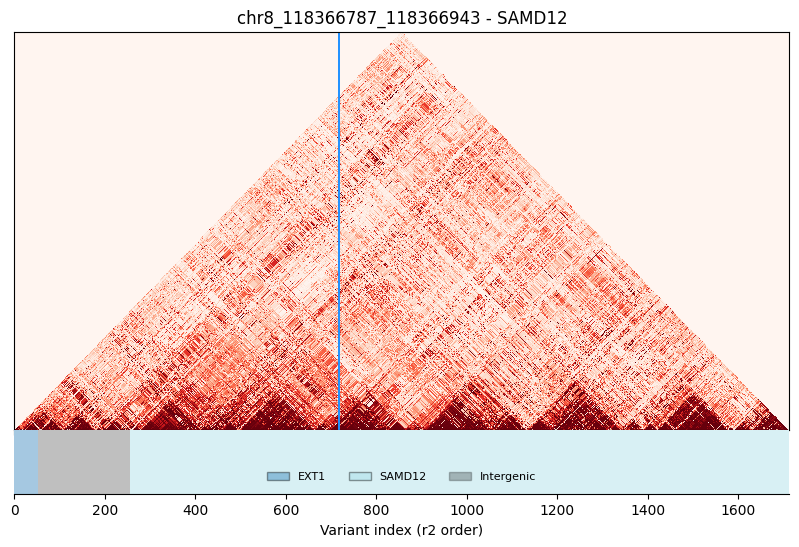

In [94]:
r2 = pairwise_ld_dprime(m, maf_min=0.05)
fig, gene_bounds = plot_ld_with_gene_spans_legend(
    r2, region_anno, gene_col='gene.1',
    trid=test['TRID'].iloc[0],
    title=test['TRID'].iloc[0] + ' - ' + test['Gene'].iloc[0]
)
plt.show()


## 10. Find lead SNP and define LD block

Lead SNP: chr8:118366744_G>A (121 bp from repeat center)
LD block: 123 variants


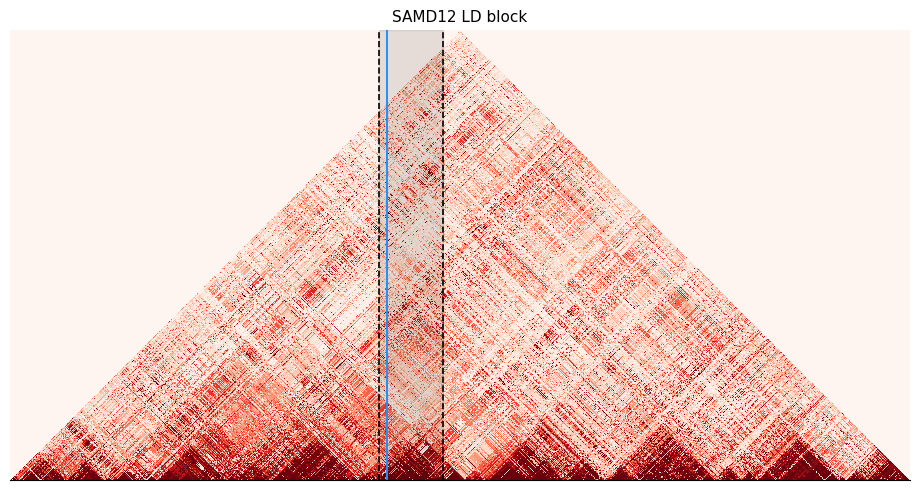

In [95]:
closest_snp, closest_snp_distance = find_closest_snp_to_trid(r2, test['TRID'].unique()[0])
print(f'Lead SNP: {closest_snp} ({closest_snp_distance:.0f} bp from repeat center)')

m_block, info = subset_m_by_best_local_ld_anchor(
    m, r2, closest_snp=closest_snp, flank=20, threshold=0.8, require_contiguous=True
)
print(f'LD block: {info["n_block_snps"]} variants')

fig, block_info = plot_ld_with_block(r2, m_block, closest_snp=closest_snp,
                                      title='SAMD12 LD block')
plt.show()


## 11. Call haplotypes

In [96]:
hap, hap_info, used_cols = make_haplotypes(m_block, k=None, missing_char='?')

hap_df = (
    pd.DataFrame({'Sample': hap.index.astype(str), 'hap_barcode': hap.astype(str)})
    .drop_duplicates('Sample')
    .merge(hap_info[['hap_barcode', 'hap_id']].drop_duplicates('hap_barcode'),
           on='hap_barcode', how='left', validate='m:1')
)

test = attach_or_update_hap(test, hap_df)
print(test['hap_id'].value_counts(dropna=False).head(15))


hap_id
H1     180
H2      77
H3      41
H4      40
H5      30
H6      28
H7      26
H8      17
H9      17
H11     15
H10     15
H12     12
H15      9
H13      9
H14      9
Name: count, dtype: int64


## 12. Group rare haplotypes and build ancestry barplot (Figure 4B)

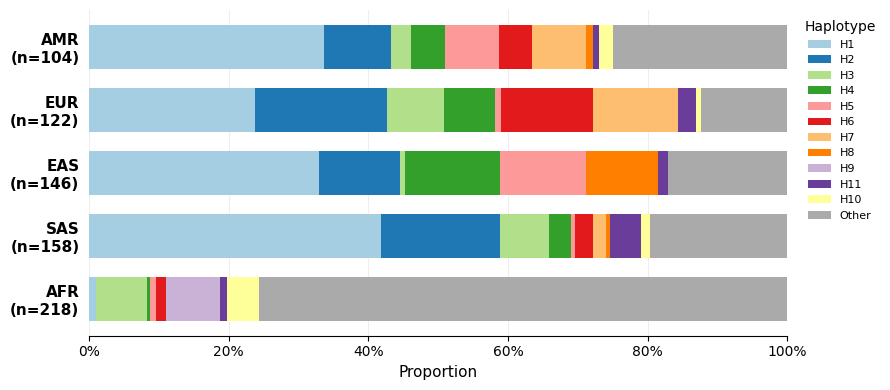

In [97]:
hap_freq = test['hap_id'].value_counts(normalize=True)
top_haps = hap_freq[hap_freq >= 0.02].index.tolist()
test['hap_group'] = test['hap_id'].where(test['hap_id'].isin(top_haps), 'Other')

pop_order = ['African', 'South Asian', 'East Asian', 'European', 'American']
ct = pd.crosstab(test['Superpopulation name'], test['hap_group'])
props = ct.div(ct.sum(axis=1), axis=0).fillna(0.0)
props = props.reindex([p for p in pop_order if p in props.index])

cols = [h for h in top_haps if h in props.columns] + (['Other'] if 'Other' in props.columns else [])
palette = {h: mpl.colormaps['Paired'](i/max(len(top_haps),1)) for i,h in enumerate(top_haps)}
palette['Other'] = '#AAAAAA'

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(props))
for hap in cols:
    if hap not in props.columns: continue
    vals = props[hap].values
    ax.barh(range(len(props)), vals, left=bottom, color=palette.get(hap,'#ccc'), label=hap, height=0.7)
    bottom += vals

pop_labels = []
for pop in props.index:
    n = int(test[test['Superpopulation name']==pop].shape[0])
    short = {'African':'AFR','American':'AMR','East Asian':'EAS','European':'EUR','South Asian':'SAS'}.get(pop,pop)
    pop_labels.append(f'{short}\n(n={n})')

ax.set_yticks(range(len(props)))
ax.set_yticklabels(pop_labels, fontsize=11, fontweight='bold')
ax.set_xlim(0,1)
ax.set_xlabel('Proportion', fontsize=11)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8, frameon=False, title='Haplotype')
for spine in ['top','right','left']: ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.xaxis.grid(True, color='#eeeeee', lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 13. Repeat length by haplotype stripplot (Figure 4C left)

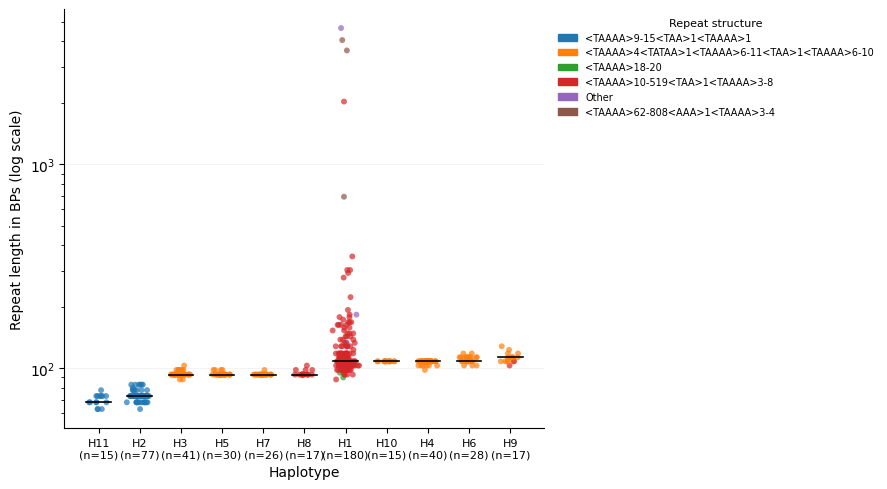

In [98]:
plot_sub = test[test['hap_id'].isin(top_haps)].copy()
hap_order = (plot_sub.groupby('hap_id')['repeatLength']
             .median().sort_values().index.tolist())

config_list = [c for c in plot_sub['assigned_haplotype'].dropna().unique()]
config_colors = {c: mpl.colormaps['tab10'](i/10) for i,c in enumerate(config_list)}

fig, ax = plt.subplots(figsize=(9,5))
for i, hap in enumerate(hap_order):
    sub = plot_sub[plot_sub['hap_id']==hap]
    np.random.seed(42)
    xs = np.random.normal(i, 0.12, size=len(sub))
    colors_pt = [config_colors.get(c,'#cccccc') for c in sub['assigned_haplotype']]
    ax.scatter(xs, sub['repeatLength'], c=colors_pt, s=18, alpha=0.7, linewidths=0, zorder=2)
    ax.plot([i-0.3, i+0.3], [sub['repeatLength'].median()]*2, color='black', lw=1.2, zorder=3)

ax.set_yscale('log')
ax.set_xticks(range(len(hap_order)))
ax.set_xticklabels([f'{h}\n(n={len(plot_sub[plot_sub["hap_id"]==h])})' for h in hap_order], fontsize=8)
ax.set_ylabel('Repeat length in BPs (log scale)', fontsize=10)
ax.set_xlabel('Haplotype', fontsize=10)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
ax.yaxis.grid(True, which='major', color='#eeeeee', lw=0.5)
ax.set_axisbelow(True)
handles = [mpatches.Patch(color=c, label=k) for k,c in config_colors.items()]
ax.legend(handles=handles, fontsize=7, frameon=False,
          bbox_to_anchor=(1.01,1), loc='upper left', title='Repeat structure', title_fontsize=8)
plt.tight_layout()
plt.show()


## 14. Haplotype network (Figure 4C right)

/var/folders/qz/5wwndvpx4_v74xllvh_p8vmm0000gn/T/ipykernel_87319/509026111.py:1758: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(col):


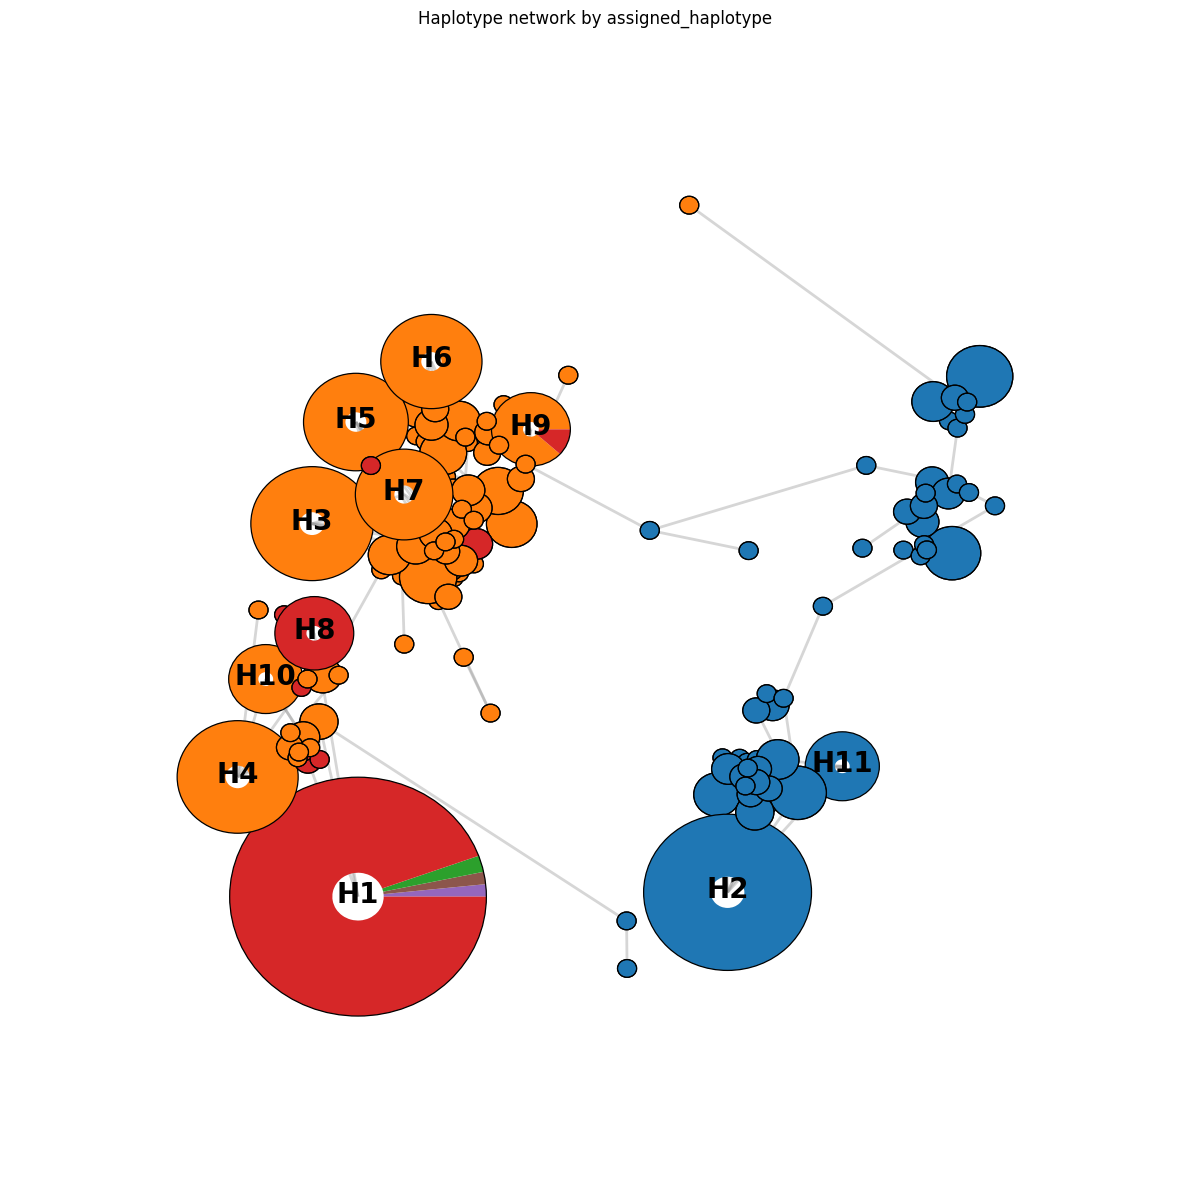

In [99]:
# Haplotype network — uses ALL haplotypes (pie charts colored by sequence configuration)
# palette = config_colors dict from assigned_haplotype (built in stripplot cell)

fig = plot_haplotype_network(
    test, hap_col='hap_id', bc_col='hap_barcode',
    group_col='assigned_haplotype', weight_groups=False,
    axes_pad=0.2, radius_scale=0.01,
    fig_pad=(0.08, 0.88, 0.08, 0.92),
    figsize=(12, 12), min_hap_count=1, overlap_pad=-0.01,
    label_min_n=15, layout='mds', color_map=config_colors, legend=False
)
plt.show()


## 15. Summary statistics

In [100]:
print('=== Key numbers for manuscript ===')
print(f'Total distinct haplotypes: {test["hap_id"].nunique()}')
print(f'H1-H11 collectively: {test["hap_id"].value_counts(normalize=True).head(11).sum()*100:.1f}% of chromosomes')
for pop in ['African','American','East Asian','European','South Asian']:
    h1 = test[test['Superpopulation name']==pop]['hap_id'].value_counts(normalize=True).get('H1',0)
    print(f'  H1 in {pop}: {h1*100:.1f}%')
expanded = test[test['repeatLength'] > 150]
print(f'Alleles > 150 bp: {len(expanded)}')
print('Haplotypes of alleles > 150 bp:')
print(expanded['hap_id'].value_counts())
print('Superpopulations of alleles > 150 bp:')
print(expanded['Superpopulation name'].value_counts())


=== Key numbers for manuscript ===
Total distinct haplotypes: 143
H1-H11 collectively: 65.0% of chromosomes
  H1 in African: 0.9%
  H1 in American: 33.7%
  H1 in East Asian: 32.9%
  H1 in European: 23.8%
  H1 in South Asian: 41.8%
Alleles > 150 bp: 29
Haplotypes of alleles > 150 bp:
hap_id
H1     28
H42     1
Name: count, dtype: int64
Superpopulations of alleles > 150 bp:
Superpopulation name
South Asian    18
East Asian     11
Name: count, dtype: int64
